In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, make_scorer

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

In [97]:
correspondance = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction\CorrespondanceIndicateursFiltre.csv")

# Dataset

## Dataset 1 Masked

#### Récupération du dataset1

Travail déjà effectué :
- Split train/test
- Scale les LCU non plus depuis tout le dataset mais seulement depuis train

Première 5763 lignes = train  
Puis 1356 prochaines = test

In [98]:
dataset1 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\eviter_data_leakage\\tulip_lifting_001.csv")
dataset1

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS,WB_WDI_SP_POP_1519_FE_5Y,WB_WDI_SP_POP_1519_MA_5Y,WB_WDI_SP_POP_2529_MA_5Y,WB_WDI_SP_POP_6569_MA_5Y,WB_WDI_SP_POP_65UP_FE_IN,WB_WDI_SP_POP_7074_FE_5Y,WB_WDI_SP_RUR_TOTL_ZG,WB_WDI_TG_VAL_TOTL_GD_ZS,war_nextYear
0,AFG,1960,NaN,15670000.0,17180000.0,1.366750e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1961,0.143791,33550000.0,34670000.0,2.684100e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1962,0.142857,15260000.0,16930000.0,1.291240e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326,0
7115,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,39.9351,10.8611,11.8183,6.34225,1.42023,326235.0,1.072400,1.61214,37.3596,0
7116,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,39.6584,10.8066,11.7868,6.25171,1.37936,335662.0,1.129590,1.63594,49.9734,0
7117,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,39.4349,10.7533,11.7626,6.24510,1.33185,344385.0,1.186100,1.57022,46.4750,0


#### Création des colonnes lags de n-3, n-2, n-1 pour l'année n (+ suppression de 1960, 1961 et 1962 car NaN dans les lags + suppression 2012 2013 2014)

In [99]:
dfs = []

for country, group in dataset1.groupby("REF_AREA"):
    group = group.sort_values("TIME_PERIOD").copy()

    cols_to_lag = [
        col for col in group.columns
        if col not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]
    ]

    lag_frames = {}
    for lag in [1, 2, 3]:
        lag_df = group[cols_to_lag].shift(lag)
        lag_df.columns = [f"{c}_lag{lag}" for c in cols_to_lag]
        lag_frames[lag] = lag_df

    group = pd.concat([group] + list(lag_frames.values()), axis=1)

    group = group.iloc[3:]

    dfs.append(group)

dataset1_lagged = pd.concat(dfs, ignore_index=True)
for annee in [2012, 2013, 2014]:
    dataset1_lagged.drop(dataset1_lagged.loc[dataset1_lagged["TIME_PERIOD"] == annee].index, inplace=True)
dataset1_lagged

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_DYN_TO65_FE_ZS_lag3,WB_WDI_SP_POP_0014_FE_ZS_lag3,WB_WDI_SP_POP_1519_FE_5Y_lag3,WB_WDI_SP_POP_1519_MA_5Y_lag3,WB_WDI_SP_POP_2529_MA_5Y_lag3,WB_WDI_SP_POP_6569_MA_5Y_lag3,WB_WDI_SP_POP_65UP_FE_IN_lag3,WB_WDI_SP_POP_7074_FE_5Y_lag3,WB_WDI_SP_RUR_TOTL_ZG_lag3,WB_WDI_TG_VAL_TOTL_GD_ZS_lag3
0,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,21.5017,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN
1,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,22.0933,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN
2,AFG,1965,0.141026,51170000.0,53930000.0,3.788620e+08,NaN,NaN,NaN,NaN,...,22.6430,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN
3,AFG,1966,0.191449,46960000.0,50840000.0,3.428130e+08,NaN,NaN,NaN,NaN,...,23.1815,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN
4,AFG,1967,1.274860,37080000.0,41080000.0,2.768730e+08,NaN,NaN,NaN,NaN,...,23.7688,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,53.5242,41.2072,10.4084,11.0975,7.18302,1.31510,278203.0,0.939711,1.51974,42.1972
6776,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,54.6176,40.9257,10.6198,11.4015,6.86392,1.37221,290120.0,0.960355,1.52996,16.7304
6777,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,56.2024,40.5995,10.7773,11.6384,6.67529,1.42400,302353.0,0.973918,1.52873,30.5890
6778,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,56.8350,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326


#### Sauvegarde du dataset en CSV

In [100]:
new_order = [col for col in dataset1_lagged.columns if col != 'war_nextYear'] + ['war_nextYear']
dataset1_lagged_final = dataset1_lagged[new_order]

dataset1_lagged_final.to_csv("dataset1_lagged_final.csv", index=False)

## Dataset 2 Interpolated

#### Récupération du dataset2

Travail déjà effectué :
- Split train/test pour
- LCU scale non plus depuis tout le dataset mais seulement depuis train
- Interpolé train et test indep.
- RobustScalé sur train, puis transform sur train et test

In [107]:
dataset2 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\eviter_data_leakage\\tulip_lifting_002.csv")
dataset2

,REF_AREA,TIME_PERIOD,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated,WB_WDI_SP_RUR_TOTL_was_interpolated,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated,WB_WDI_SP_URB_GROW_was_interpolated,WB_WDI_SP_URB_TOTL_was_interpolated,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated,war_nextYear
0,AFG,1960,-0.010893,-0.159762,-0.163586,-0.018595,0.168217,0.569609,1.676921,1.701582,...,False,False,False,False,False,False,True,False,False,0
1,AFG,1961,-0.010893,-0.159337,-0.163188,-0.018595,0.255945,0.560755,1.645384,1.663908,...,False,False,False,False,False,False,False,False,False,0
2,AFG,1962,-0.010893,-0.159337,-0.163188,-0.018595,0.278659,0.555477,1.616882,1.629630,...,False,False,False,False,False,False,False,False,False,0
3,AFG,1963,-0.010893,-0.159337,-0.163188,-0.018595,0.270270,0.555559,1.589105,1.597300,...,False,False,False,False,False,False,False,False,False,0
4,AFG,1964,-0.010893,-0.159337,-0.163188,-0.018595,0.280237,0.560557,1.559453,1.563872,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,ZWE,2019,3.624107,0.313896,0.360988,36.741186,-2.479208,0.081857,0.484677,0.474558,...,False,False,False,False,False,False,False,False,False,0
7115,ZWE,2020,3.788446,0.277513,0.330573,31.555576,-2.136938,0.083721,0.410134,0.438263,...,False,False,False,False,False,False,False,False,False,0
7116,ZWE,2021,0.892289,0.307427,0.294076,74.489079,-1.765868,0.087286,0.598119,0.702972,...,False,False,False,False,False,False,False,False,False,0
7117,ZWE,2022,1.480716,0.274178,0.276045,74.489079,-2.472220,0.090607,0.340137,0.368417,...,False,False,False,False,False,False,False,False,False,0


#### Standard Scaler pour PCA

In [110]:
def StandardisationStandard(train, test, cols_to_scale):
    train_scaled = train.copy()
    test_scaled = test.copy()

    train_log = train.copy()
    test_log = test.copy()
    
    scaler = StandardScaler()
    scaler.fit(train_log[cols_to_scale])

    train_scaled[cols_to_scale] = scaler.transform(train_log[cols_to_scale]) 
    test_scaled[cols_to_scale] = scaler.transform(test_log[cols_to_scale]) 
    
    return train_scaled, test_scaled
    

dataset2_to_scaled = dataset2.copy()
train = dataset2_to_scaled[dataset2_to_scaled["TIME_PERIOD"] <= 2010]
test = dataset2_to_scaled[dataset2_to_scaled["TIME_PERIOD"] >= 2012]
X_train = train.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])

cols_to_scale = [
    c for c in train.columns 
    if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"] and "_was_interpolated" not in c
]

train_scaledStandard, test_scaledStandard = StandardisationStandard(train, test, cols_to_scale)
dataset2_scaled = pd.concat([train_scaledStandard, test_scaledStandard])
dataset2_scaled

,REF_AREA,TIME_PERIOD,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated,WB_WDI_SP_RUR_TOTL_was_interpolated,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated,WB_WDI_SP_URB_GROW_was_interpolated,WB_WDI_SP_URB_TOTL_was_interpolated,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated,war_nextYear
0,AFG,1960,-0.088834,-0.329701,-0.203842,-0.097799,0.035187,0.893428,2.623997,2.341211,...,False,False,False,False,False,False,True,False,False,0
1,AFG,1961,-0.088834,-0.329624,-0.203808,-0.097799,0.055696,0.878806,2.572264,2.288369,...,False,False,False,False,False,False,False,False,False,0
2,AFG,1962,-0.088834,-0.329624,-0.203808,-0.097799,0.061007,0.870091,2.525509,2.240290,...,False,False,False,False,False,False,False,False,False,0
3,AFG,1963,-0.088834,-0.329624,-0.203808,-0.097799,0.059045,0.870226,2.479945,2.194942,...,False,False,False,False,False,False,False,False,False,0
4,AFG,1964,-0.088834,-0.329624,-0.203808,-0.097799,0.061375,0.878479,2.431304,2.148056,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,ZWE,2019,-0.078254,-0.243774,-0.158952,0.125549,-0.583734,0.087979,0.668251,0.620161,...,False,False,False,False,False,False,False,False,False,0
7115,ZWE,2020,-0.077776,-0.250375,-0.161555,0.094042,-0.503718,0.091058,0.545971,0.569252,...,False,False,False,False,False,False,False,False,False,0
7116,ZWE,2021,-0.086205,-0.244948,-0.164678,0.354900,-0.416968,0.096945,0.854341,0.940539,...,False,False,False,False,False,False,False,False,False,0
7117,ZWE,2022,-0.084492,-0.250979,-0.166221,0.354900,-0.582101,0.102428,0.431149,0.471284,...,False,False,False,False,False,False,False,False,False,0


#### Création des colonnes lags de n-3, n-2, n-1 pour l'année n (+ suppression de 1960, 1961 et 1962 car NaN dans les lags)

In [113]:
def create_lag(dataset2):
    dfs = []

    for country, group in dataset2.groupby("REF_AREA"):
        group = group.sort_values("TIME_PERIOD").copy()

        cols_to_lag = [
            col for col in group.columns
            if col not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]
        ]

        lag_frames = {}
        for lag in [1, 2, 3]:
            lag_df = group[cols_to_lag].shift(lag)
            lag_df.columns = [f"{c}_lag{lag}" for c in cols_to_lag]
            lag_frames[lag] = lag_df

        group = pd.concat([group] + list(lag_frames.values()), axis=1)

        group = group.iloc[3:]

        dfs.append(group)

    dataset2_lagged = pd.concat(dfs, ignore_index=True)
    for annee in [2012, 2013, 2014]:
        dataset2_lagged.drop(dataset2_lagged.loc[dataset2_lagged["TIME_PERIOD"] == annee].index, inplace=True)

    return dataset2_lagged

dataset2_lagged = create_lag(dataset2)
dataset2_scaled_lagged = create_lag(dataset2_scaled)

#### Vérification 0 NaN dans dataset2 même avec colonnes lagged

In [115]:
print(dataset2_lagged.isna().sum().sum())
print(dataset2_scaled_lagged.isna().sum().sum())

0
0


#### Réorganisation colonne avec war_nextYear à la fin + Sauvegarde du dataset en CSV

In [117]:
cols = ['war']
new_order = [col for col in dataset2_lagged.columns if col != 'war_nextYear'] + ['war_nextYear']
dataset2_lagged_final = dataset2_lagged[new_order]

dataset2_lagged_final.to_csv("dataset2_lagged_final.csv", index=False)

#### PCA (optionnel)

Original shape : (5763, 166)
After PCA shape: (5763, 2)
Explained variance: 0.99671781607833
Shape train_pca_final : (5763, 5)
Shape test_pca_final  : (1356, 5)

Top variables for PC1:
WB_WDI_ER_FSH_AQUA_MT       0.946672
WB_WDI_NY_ADJ_DMIN_CD       0.317037
WB_WDI_ER_FSH_PROD_MT       0.030409
WB_WDI_SP_POP_65UP_MA_IN    0.017542
WB_WDI_SP_POP_65UP_TO       0.017360
Name: PC1, dtype: float64

Top variables for PC2:
WB_WDI_NY_ADJ_DMIN_CD       0.948330
WB_WDI_ER_FSH_AQUA_MT       0.316186
WB_WDI_SP_RUR_TOTL          0.011866
WB_WDI_ER_FSH_PROD_MT       0.008465
WB_WDI_SP_POP_1564_MA_IN    0.007204
Name: PC2, dtype: float64


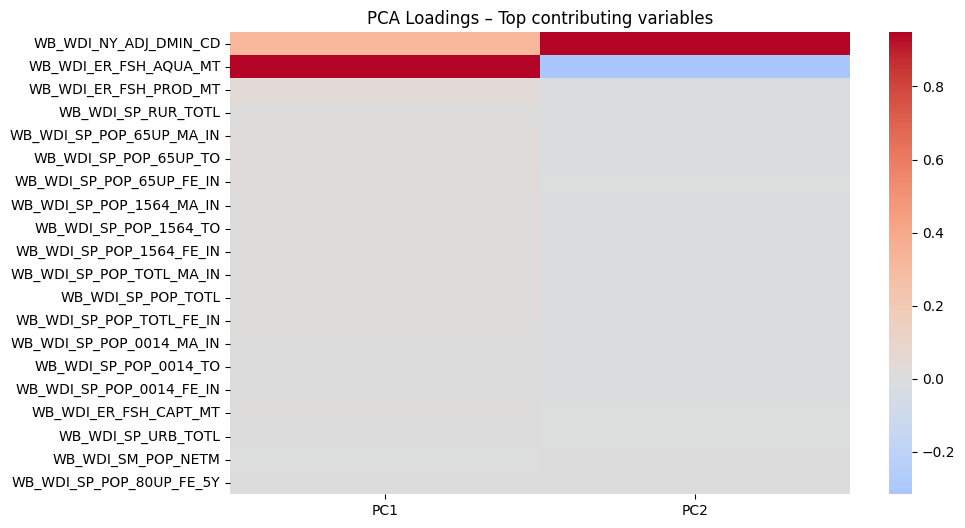

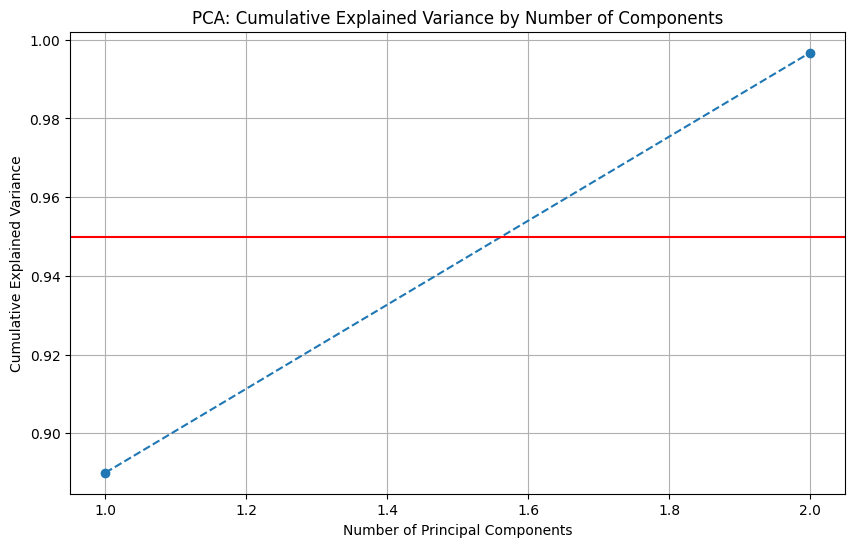

In [118]:
dataset2_scaled_lagged = dataset2.copy()
train = dataset2_scaled_lagged[dataset2_scaled_lagged["TIME_PERIOD"] <= 2010]
test = dataset2_scaled_lagged[dataset2_scaled_lagged["TIME_PERIOD"] >= 2012]
X_train = train.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print("Original shape :", X_train.shape)
print("After PCA shape:", X_train_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

pca_columns = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_columns,
    index=train.index
)
X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=pca_columns,
    index=test.index
)

train_pca_final = pd.concat(
    [
        train[["REF_AREA", "TIME_PERIOD"]].reset_index(drop=True),
        X_train_pca_df.reset_index(drop=True),
        train["war_nextYear"].reset_index(drop=True)
    ],
    axis=1
)
test_pca_final = pd.concat(
    [
        test[["REF_AREA", "TIME_PERIOD"]].reset_index(drop=True),
        X_test_pca_df.reset_index(drop=True),
        test["war_nextYear"].reset_index(drop=True)
    ],
    axis=1
)

print("Shape train_pca_final :", train_pca_final.shape)
print("Shape test_pca_final  :", test_pca_final.shape)

dataset2_lagged_pca_final = pd.concat(
    [train_pca_final, test_pca_final],
    axis=0
).reset_index(drop=True)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
for pc in ["PC1", "PC2"]:
    print(f"\nTop variables for {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))

top_vars = loadings.abs().sum(axis=1).sort_values(ascending=False).head(20).index
plt.figure(figsize=(10,6))
sns.heatmap(loadings.loc[top_vars], cmap="coolwarm", center=0)
plt.title("PCA Loadings – Top contributing variables")
plt.show()

dataset2_lagged_pca_final.to_csv("dataset2_lagged_pca_final.csv", index=False)

# Variance expliquée par chaque composante
explained_variance_ratio = pca.explained_variance_ratio_
# Variance cumulative
cumulative_variance = explained_variance_ratio.cumsum()
plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')  # ligne à 95%
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance by Number of Components')
plt.grid(True)
plt.show()

In [ ]:
cols = ['war']
new_order = [col for col in dataset2_lagged.columns if col != 'war_nextYear'] + ['war_nextYear']
dataset2_lagged_final = dataset2_lagged[new_order]

dataset2_lagged_final.to_csv("dataset2_lagged_final.csv", index=False)

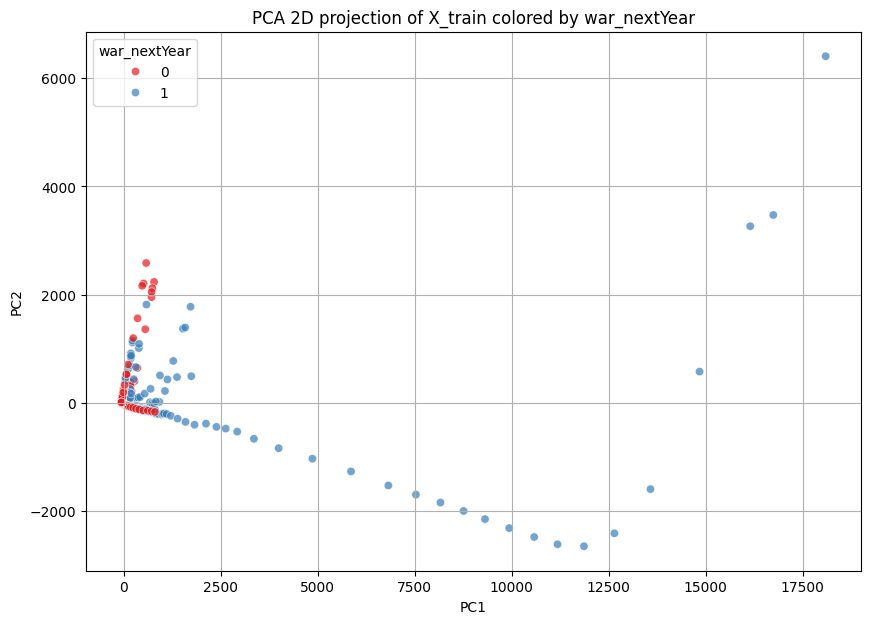

In [12]:
# Extraire les 2 premières composantes
X_2d = X_train_pca_df[['PC1', 'PC2']]

# Créer un DataFrame avec la target
plot_df = X_2d.copy()
plot_df['war_nextYear'] = train['war_nextYear'].values  # target

# Plot avec seaborn
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='war_nextYear',        # couleur selon la target
    palette='Set1',            # palette de couleurs
    alpha=0.7
)
plt.title("PCA 2D projection of X_train colored by war_nextYear")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="war_nextYear")
plt.grid(True)
plt.show()

# Train

## Dataset 1 Masked

#### Récupération du dataset1

In [4]:
dataset1 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset1_lagged_final.csv")
dataset1

,REF_AREA,TIME_PERIOD,WB_WDI_AG_CON_FERT_ZS,WB_WDI_DC_DAC_TOTL_CD,WB_WDI_DT_ODA_ALLD_CD,WB_WDI_DT_ODA_ODAT_KD,WB_WDI_EN_GHG_CH4_MT_CE_AR5,WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5,WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5,WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5,...,WB_WDI_SP_POP_0014_FE_ZS_lag3,WB_WDI_SP_POP_1519_FE_5Y_lag3,WB_WDI_SP_POP_1519_MA_5Y_lag3,WB_WDI_SP_POP_2529_MA_5Y_lag3,WB_WDI_SP_POP_6569_MA_5Y_lag3,WB_WDI_SP_POP_65UP_FE_IN_lag3,WB_WDI_SP_POP_7074_FE_5Y_lag3,WB_WDI_SP_RUR_TOTL_ZG_lag3,WB_WDI_TG_VAL_TOTL_GD_ZS_lag3,war_nextYear
0,AFG,1963,0.141935,34880000.0,36670000.0,2.767830e+08,NaN,NaN,NaN,NaN,...,43.3717,10.2806,10.1839,7.82277,1.44769,117264.0,0.808173,NaN,NaN,0
1,AFG,1964,0.141026,44220000.0,46170000.0,3.395140e+08,NaN,NaN,NaN,NaN,...,43.3638,10.4078,10.2202,7.79233,1.42514,119751.0,0.805887,1.65281,NaN,0
2,AFG,1965,0.141026,51170000.0,53930000.0,3.788620e+08,NaN,NaN,NaN,NaN,...,43.3353,10.5532,10.2384,7.77287,1.39832,122340.0,0.803893,1.72425,NaN,0
3,AFG,1966,0.191449,46960000.0,50840000.0,3.428130e+08,NaN,NaN,NaN,NaN,...,43.3200,10.6760,10.1932,7.75797,1.37074,125012.0,0.802343,1.77508,NaN,0
4,AFG,1967,1.274860,37080000.0,41080000.0,2.768730e+08,NaN,NaN,NaN,NaN,...,43.3633,10.7217,10.0999,7.73494,1.34735,127775.0,0.801164,1.81891,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6436,ZWE,2019,32.932400,577796000.0,845411000.0,9.534840e+08,12.6850,1.1786,4.9028,0.3527,...,41.2072,10.4084,11.0975,7.18302,1.31510,278203.0,0.939711,1.51974,42.1972,0
6437,ZWE,2020,20.196900,690017000.0,986310000.0,1.078180e+09,12.9927,1.3046,3.7607,0.3669,...,40.9257,10.6198,11.4015,6.86392,1.37221,290120.0,0.960355,1.52996,16.7304,0
6438,ZWE,2021,36.868900,644530000.0,987395000.0,1.027870e+09,13.3484,1.8878,3.8771,0.3686,...,40.5995,10.7773,11.6384,6.67529,1.42400,302353.0,0.973918,1.52873,30.5890,0
6439,ZWE,2022,30.780700,524583000.0,788073000.0,8.243410e+08,13.8533,1.7723,4.2559,0.3699,...,40.2581,10.8588,11.7774,6.49447,1.44292,314683.0,1.010200,1.56206,35.3326,0


<Figure size 1200x1200 with 0 Axes>

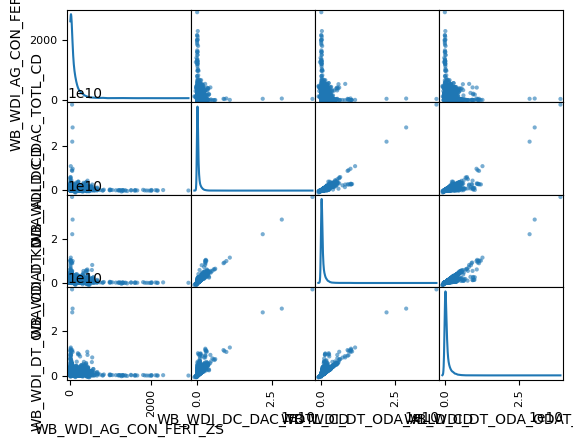

In [7]:
cols_subset = dataset1.select_dtypes(include='number').columns[1:5]

plt.figure(figsize=(12,12))
pd.plotting.scatter_matrix(dataset1[cols_subset], alpha=0.6, diagonal='kde')  # 'kde' pour la distribution sur la diagonale
plt.show()

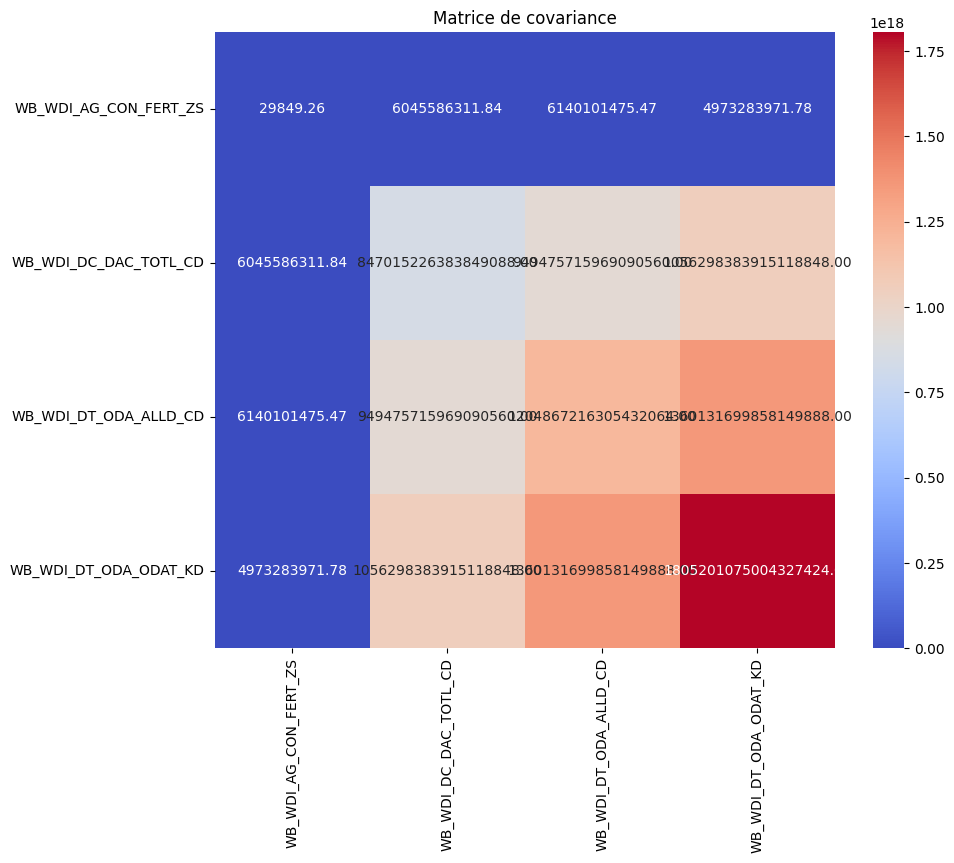

In [9]:
cols_subset = dataset1.select_dtypes(include='number').columns[1:5]
cov_matrix = dataset1[cols_subset].cov()

# numeric_df = dataset1.select_dtypes(include='number')
# cov_matrix = numeric_df.cov()

plt.figure(figsize=(10,8))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de covariance")
plt.show()

In [10]:
cols_to_check = [c for c in dataset1.columns if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]]
data_numeric = dataset1[cols_to_check]
corr_matrix = data_numeric.corr().abs()
threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

print(f"Colonnes à supprimer ({len(to_drop)}):", to_drop)
dataset1 = dataset1.drop(columns=list(to_drop))
print("Shape après réduction :", dataset1.shape)

Colonnes à supprimer (630): {'WB_WDI_SP_URB_TOTL_lag1', 'WB_WDI_IT_MLT_MAIN_P2_lag1', 'WB_WDI_TX_VAL_MRCH_CD_WT_lag2', 'WB_WDI_SP_DYN_TFRT_IN_lag2', 'WB_WDI_EN_GHG_N2O_TR_MT_CE_AR5_lag2', 'WB_WDI_NE_TRD_GNFS_ZS_lag1', 'WB_WDI_EN_GHG_N2O_IP_MT_CE_AR5_lag2', 'WB_WDI_SP_POP_5559_FE_5Y_lag1', 'WB_WDI_SP_POP_0509_MA_5Y', 'WB_WDI_SH_DYN_NMRT_lag2', 'WB_WDI_NY_GDP_PCAP_KD_lag1', 'WB_WDI_SP_POP_4549_FE_5Y_lag1', 'WB_WDI_SP_POP_80UP_FE_5Y_lag1', 'WB_WDI_SH_DYN_MORT_MA_lag2', 'WB_WDI_SP_POP_TOTL_FE_ZS_lag3', 'WB_WDI_AG_LND_AGRI_ZS_lag3', 'WB_WDI_NE_TRD_GNFS_ZS_lag3', 'WB_WDI_EN_GHG_N2O_TR_MT_CE_AR5_lag1', 'WB_WDI_EN_GHG_CH4_IC_MT_CE_AR5_lag1', 'WB_WDI_EN_GHG_N2O_AG_MT_CE_AR5_lag3', 'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5_lag3', 'WB_WDI_ER_FSH_AQUA_MT_lag1', 'WB_WDI_EN_URB_MCTY_lag3', 'WB_WDI_EN_GHG_CH4_FE_MT_CE_AR5_lag3', 'WB_WDI_SP_POP_0014_TO_ZS_lag1', 'WB_WDI_SP_POP_6064_FE_5Y_lag1', 'WB_WDI_SP_POP_1564_TO_lag3', 'WB_WDI_SP_ADO_TFRT_lag2', 'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5_lag2', 'WB_WDI_EN_GHG_CH4_BU_

#### Découpage train/validation/test

In [11]:
train_full = dataset1[dataset1["TIME_PERIOD"] <= 2010]
test  = dataset1[dataset1["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset1   => {dataset1.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

Dataset1   => (6441, 253)
Train_full => (5424, 253)
Test       => (1017, 253)
Train_full : X_train_full => (5424, 250) - y_train_full => (5424,)
Test       : X_test       => (1017, 250) - y_test       => (1017,)
X_train_train => (4407, 250)
y_train_train => (4407,)
X_train_val   => (1017, 250)
y_train_val   => (1017,)


#### XGBoost

##### Hyperparameter tunning

In [12]:
# scale_pos_weight = y_train_full.value_counts()[0] / y_train_full.value_counts()[1]

# # Définition du modèle
# xgb_model = xgb.XGBClassifier(
#     scale_pos_weight=scale_pos_weight,
#     random_state=42,
#     eval_metric='logloss',
#     n_jobs=-1
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)


##### Entraînement avec meilleur hyperparamètre

In [13]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_xgb = xgb.XGBClassifier(
    n_estimators=300, #100
    max_depth=7, #3
    learning_rate=0.1, #0.05
    subsample=0.8, #1.0
    colsample_bytree=1.0, #0.8
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
    # objective="binary:logistic",
    # use_label_encoder=False
)

# Entraînement
model_xgb.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_train, y_train_train), (X_train_val, y_train_val)], 
    # eval_set=[(X_train_val, y_train_val)], 
    # early_stopping_rounds=30,
    verbose=False
)

# Prédiction
y_val_pred = model_xgb.predict(X_train_val)

# Évaluation
acc_xgb_d1 = accuracy_score(y_train_val, y_val_pred)
f1_xgb_d1 = f1_score(y_train_val, y_val_pred)
precision_xgb_d1 = precision_score(y_train_val, y_val_pred)
recall_xgb_d1 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_xgb_d1)
print("F1-score :", f1_xgb_d1)
print("Precision:", precision_xgb_d1)
print("Recall   :", recall_xgb_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.9292035398230089
F1-score : 0.9192825112107623
Precision: 0.9172259507829977
Recall   : 0.9213483146067416

Confusion matrix:
 [[535  37]
 [ 35 410]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       572
           1       0.92      0.92      0.92       445

    accuracy                           0.93      1017
   macro avg       0.93      0.93      0.93      1017
weighted avg       0.93      0.93      0.93      1017



##### Feature importance

Top 20 features par importance :
                           Feature  Importance
0            WB_WDI_AG_LND_CREL_HA    0.110474
1            WB_WDI_AG_LND_PRCP_MM    0.022648
2       WB_WDI_DC_DAC_DEUL_CD_lag1    0.020568
3               WB_WDI_SG_LAW_INDX    0.019512
4            WB_WDI_DC_DAC_DEUL_CD    0.018005
5         WB_WDI_SP_POP_0014_FE_IN    0.012899
6       WB_WDI_DT_ODA_ODAT_KD_lag3    0.012777
7         WB_WDI_BX_GRT_EXTA_CD_WD    0.012536
8            WB_WDI_AG_LND_AGRI_K2    0.011999
9            WB_WDI_NV_AGR_TOTL_ZS    0.011763
10   WB_WDI_TX_VAL_MRCH_WR_ZS_lag3    0.011396
11        WB_WDI_SP_POP_65UP_FE_ZS    0.010868
12           WB_WDI_AG_LND_ARBL_HA    0.009959
13           WB_WDI_ER_H2O_INTR_K3    0.009431
14   WB_WDI_TX_VAL_MRCH_WR_ZS_lag2    0.009377
15        WB_WDI_NY_ADJ_AEDU_GN_ZS    0.009371
16      WB_WDI_FM_AST_DOMS_CN_lag3    0.009300
17  WB_WDI_EN_GHG_CH4_WA_MT_CE_AR5    0.008744
18        WB_WDI_TX_VAL_MRCH_R6_ZS    0.008736
19           WB_WDI_ER_FSH_

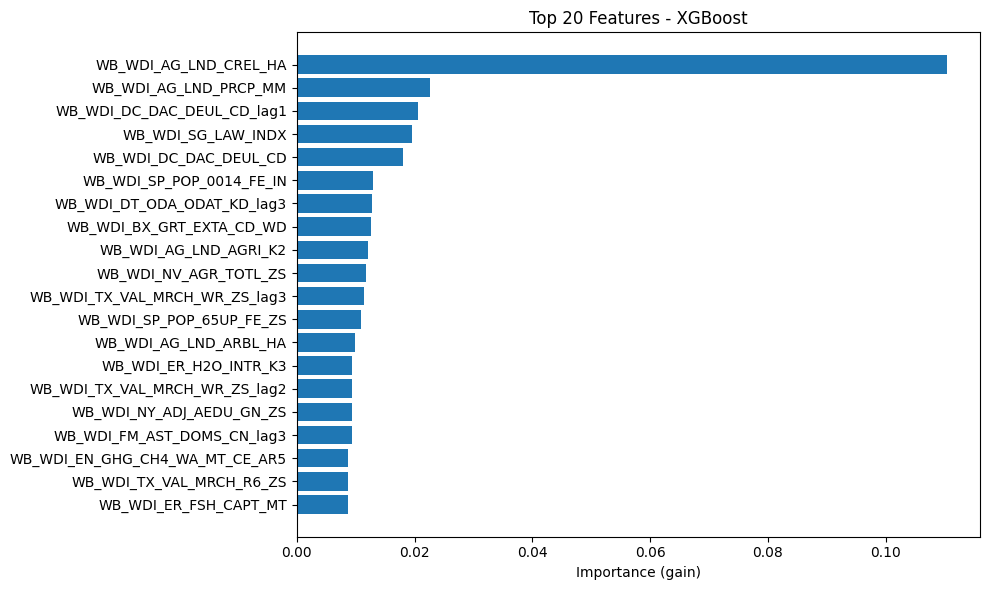

In [16]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_xgb

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

# Récupérer la feature importance par gain
importance_dict = best_model.get_booster().get_score(importance_type='gain')

# Convertir en DataFrame pour trier et afficher
importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher le tableau complet ou top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'].head(20)[::-1],
    importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (gain)')
plt.title('Top 20 Features - XGBoost')
plt.tight_layout()
plt.show()

In [17]:
# # Assurer que ton modèle est déjà entraîné : best_model = model_xgb
# best_model = model_xgb

# # 1️⃣ Créer l'explainer SHAP pour XGBoost
# explainer = shap.TreeExplainer(best_model)

# # 2️⃣ Calculer les valeurs SHAP sur l'ensemble d'entraînement
# shap_values = explainer.shap_values(X_train_train.astype(np.float32).values)

# # 3️⃣ Moyenne des valeurs absolues par feature pour obtenir l'importance globale
# shap_importance = np.abs(shap_values).mean(axis=0)

# # 4️⃣ Créer un DataFrame pour trier
# importance_df = pd.DataFrame({
#     'Feature': X_train_train.columns,
#     'SHAP Importance': shap_importance
# }).sort_values(by='SHAP Importance', ascending=False).reset_index(drop=True)

# # 5️⃣ Afficher les 20 premières features
# print("Top 20 features par SHAP importance :")
# print(importance_df.head(20))

# # 6️⃣ Graphique top 20
# plt.figure(figsize=(10,6))
# plt.barh(
#     importance_df['Feature'].head(20)[::-1],
#     importance_df['SHAP Importance'].head(20)[::-1]
# )
# plt.xlabel('Mean |SHAP value|')
# plt.title('Top 20 Features - SHAP Importance (XGBoost)')
# plt.tight_layout()
# plt.show()


#### CatBoost

##### Hyperparameter tunning

In [18]:
# # Définition du modèle
# cat_model = CatBoostClassifier(
#     random_state=42,
#     verbose=0   # IMPORTANT pour GridSearch
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'depth': [3, 5, 7],                 # max_depth → depth
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bylevel': [0.7, 0.8, 1.0]  # colsample_bytree → colsample_bylevel
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=cat_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)


##### Entraînement avec meilleur hyperparamètre

In [19]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],   # Classe 0 = poids 1, classe 1 = poids > 1
    random_seed=42,
    eval_metric="F1",
    loss_function="Logloss",
    verbose=0,
    early_stopping_rounds=30,
    # task_type="CPU",
)

# Entraînement
model_cat.fit(
    X_train_train, 
    y_train_train,
    eval_set=(X_train_val, y_train_val),
    verbose=0,           # affiche toutes les 50 itérations, mettre 0 pour silence total
    plot=False
)

# Prédiction
y_val_pred = model_cat.predict(X_train_val)

# Évaluation
acc_cat_d1 = accuracy_score(y_train_val, y_val_pred)
f1_cat_d1 = f1_score(y_train_val, y_val_pred)
precision_cat_d1 = precision_score(y_train_val, y_val_pred)
recall_cat_d1 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_cat_d1)
print("F1-score :", f1_cat_d1)
print("Precision:", precision_cat_d1)
print("Recall   :", recall_cat_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8898721730580138
F1-score : 0.880085653104925
Precision: 0.8404907975460123
Recall   : 0.9235955056179775

Confusion matrix:
 [[494  78]
 [ 34 411]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90       572
           1       0.84      0.92      0.88       445

    accuracy                           0.89      1017
   macro avg       0.89      0.89      0.89      1017
weighted avg       0.89      0.89      0.89      1017



##### Feature importance

Top 20 features par importance :
                       Feature  Importance
0        WB_WDI_AG_LND_CREL_HA    6.947939
1     WB_WDI_SP_POP_0014_FE_IN    4.590607
2        WB_WDI_SP_POP_BRTH_MF    2.728674
3        WB_WDI_AG_LND_AGRI_ZS    2.163607
4           WB_WDI_EN_POP_DNST    2.153939
5           WB_WDI_SG_LAW_INDX    2.103756
6     WB_WDI_AG_LND_ARBL_HA_PC    2.033334
7        WB_WDI_ER_H2O_INTR_K3    1.883713
8     WB_WDI_EN_URB_MCTY_TL_ZS    1.827314
9        WB_WDI_AG_LND_PRCP_MM    1.799949
10    WB_WDI_EN_URB_LCTY_UR_ZS    1.546528
11       WB_WDI_NY_GDP_PCAP_KD    1.517198
12       WB_WDI_AG_LND_ARBL_ZS    1.470843
13    WB_WDI_SP_POP_65UP_FE_ZS    1.451496
14       WB_WDI_AG_LND_AGRI_K2    1.450545
15       WB_WDI_SP_DYN_AMRT_MA    1.424324
16  WB_WDI_NY_GDP_DEFL_ZS_lag1    1.319786
17          WB_WDI_SH_DYN_MORT    1.294277
18       WB_WDI_NY_GNP_PCAP_CD    1.252303
19    WB_WDI_SP_POP_5559_FE_5Y    1.155771


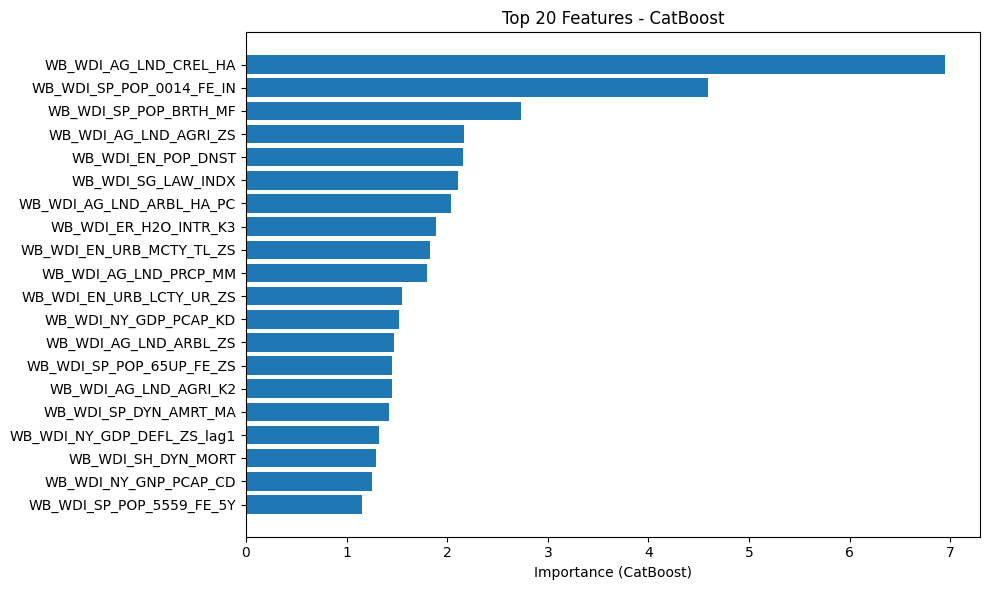

In [20]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_cat

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.get_feature_importance()

# Construire le DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Trier
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (CatBoost)')
plt.title('Top 20 Features - CatBoost')
plt.tight_layout()
plt.show()


#### Random Forest

##### Hyperparameter tunning

In [21]:
# # Définition du modèle
# rf_model = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5],
#     'max_features': ['sqrt', 'log2']
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=rf_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)


##### Entraînement avec meilleur hyperparamètre

In [22]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15, # Pour limiter overfitting, sinon None
    # class_weight={0: 1, 1: scale_pos_weight},   # équivalent au class_weights catboost
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entraînement
model_rf.fit(
    X_train_train, 
    y_train_train
)

# Prédiction
y_val_pred = model_rf.predict(X_train_val)

# Évaluation
acc_rf_d1 = accuracy_score(y_train_val, y_val_pred)
f1_rf_d1 = f1_score(y_train_val, y_val_pred)
precision_rf_d1 = precision_score(y_train_val, y_val_pred)
recall_rf_d1 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_rf_d1)
print("F1-score :", f1_rf_d1)
print("Precision:", precision_rf_d1)
print("Recall   :", recall_rf_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.9193706981317601
F1-score : 0.9088888888888889
Precision: 0.8989010989010989
Recall   : 0.9191011235955057

Confusion matrix:
 [[526  46]
 [ 36 409]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       572
           1       0.90      0.92      0.91       445

    accuracy                           0.92      1017
   macro avg       0.92      0.92      0.92      1017
weighted avg       0.92      0.92      0.92      1017



##### Feature importance

Top 20 features par importance :
                           Feature  Importance
0            WB_WDI_AG_LND_CREL_HA    0.026316
1         WB_WDI_SP_POP_0014_FE_IN    0.026128
2               WB_WDI_SH_DTH_MORT    0.020935
3            WB_WDI_AG_LND_ARBL_HA    0.017673
4            WB_WDI_ER_H2O_INTR_K3    0.012748
5               WB_WDI_EN_POP_DNST    0.012000
6            WB_WDI_NY_GDP_PCAP_KD    0.011059
7         WB_WDI_EN_URB_MCTY_TL_ZS    0.011056
8            WB_WDI_AG_LND_ARBL_ZS    0.010895
9               WB_WDI_EN_URB_LCTY    0.010246
10      WB_WDI_DC_DAC_DEUL_CD_lag2    0.009904
11  WB_WDI_EN_GHG_N2O_WA_MT_CE_AR5    0.009795
12           WB_WDI_DT_ODA_ODAT_KD    0.009744
13           WB_WDI_DC_DAC_DEUL_CD    0.008941
14  WB_WDI_EN_GHG_CH4_BU_MT_CE_AR5    0.008394
15        WB_WDI_EN_URB_LCTY_UR_ZS    0.008228
16           WB_WDI_AG_LND_AGRI_ZS    0.007910
17      WB_WDI_DT_ODA_ODAT_KD_lag1    0.007573
18           WB_WDI_AG_LND_TOTL_K2    0.007537
19           WB_WDI_AG_LND_

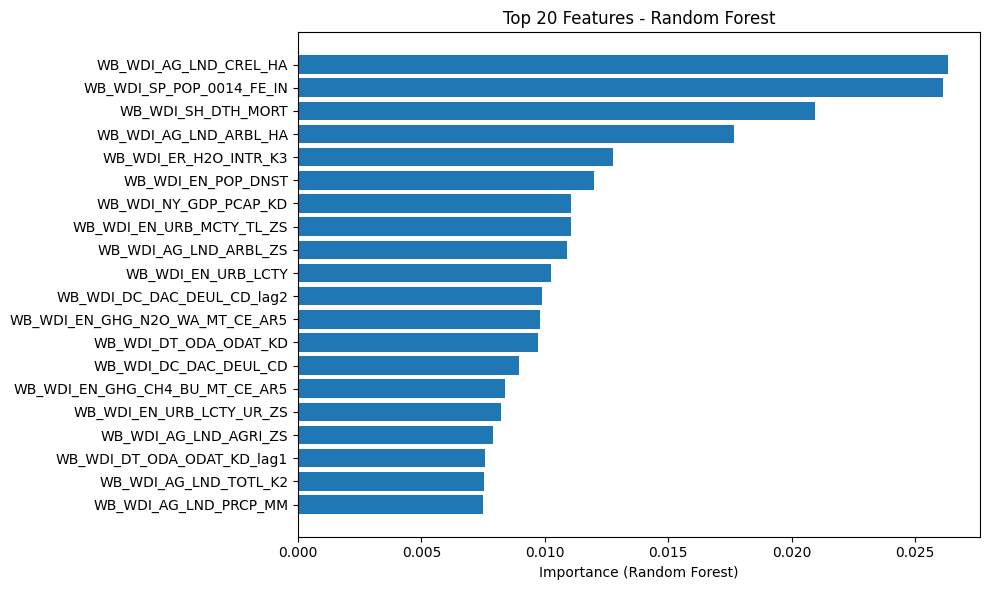

In [23]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_rf

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features par importance :")
print(importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (Random Forest)')
plt.title('Top 20 Features - Random Forest')
plt.tight_layout()
plt.show()


#### LightBM

##### Hyperparameter tunning

In [24]:
# # Définition du modèle
# lgb_model = lgb.LGBMClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# # Grille de paramètres à tester
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }

# # TimeSeriesSplit : 5 folds
# tscv = TimeSeriesSplit(n_splits=5)

# # Scorer : on optimise le F1-score
# f1_scorer = make_scorer(f1_score)

# # GridSearchCV avec TimeSeriesSplit
# grid_search = GridSearchCV(
#     estimator=lgb_model,
#     param_grid=param_grid,
#     scoring=f1_scorer,
#     cv=tscv,
#     verbose=1,
#     n_jobs=-1
# )

# # Lancement du tuning
# grid_search.fit(X_train_full, y_train_full)

# # Résultats
# print("Meilleurs paramètres :", grid_search.best_params_)
# print("Meilleur F1-score :", grid_search.best_score_)

##### Entraînement avec meilleur hyperparamètre

In [25]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    objective='binary',
    # early_stopping_rounds=30,
    verbose=0
)

# Entraînement
model_lgb.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_val, y_train_val)], 
    eval_metric='binary_logloss'
)

# Prédiction
y_val_pred = model_lgb.predict(X_train_val)

# Évaluation
acc_lgb_d1 = accuracy_score(y_train_val, y_val_pred)
f1_lgb_d1 = f1_score(y_train_val, y_val_pred)
precision_lgb_d1 = precision_score(y_train_val, y_val_pred)
recall_lgb_d1 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_lgb_d1)
print("F1-score :", f1_lgb_d1)
print("Precision:", precision_lgb_d1)
print("Recall   :", recall_lgb_d1)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.9252704031465093
F1-score : 0.9149888143176734
Precision: 0.910913140311804
Recall   : 0.9191011235955057

Confusion matrix:
 [[532  40]
 [ 36 409]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       572
           1       0.91      0.92      0.91       445

    accuracy                           0.93      1017
   macro avg       0.92      0.92      0.92      1017
weighted avg       0.93      0.93      0.93      1017



##### Feature importance

Top 20 features par importance :
                     Feature  Importance
0      WB_WDI_ER_H2O_INTR_K3         151
1   WB_WDI_SP_POP_0014_FE_IN         148
2   WB_WDI_EN_URB_MCTY_TL_ZS         141
3   WB_WDI_EN_URB_LCTY_UR_ZS         125
4         WB_WDI_EN_POP_DNST         120
5      WB_WDI_SP_POP_BRTH_MF         115
6      WB_WDI_NY_GDP_PCAP_KD         102
7   WB_WDI_AG_LND_ARBL_HA_PC         101
8      WB_WDI_ER_H2O_INTR_PC         101
9      WB_WDI_SP_DYN_AMRT_MA         100
10        WB_WDI_SH_DTH_MORT          99
11        WB_WDI_SG_LAW_INDX          96
12     WB_WDI_AG_LND_CROP_ZS          91
13        WB_WDI_SH_DYN_MORT          89
14        WB_WDI_SP_ADO_TFRT          87
15     WB_WDI_AG_LND_PRCP_MM          85
16     WB_WDI_AG_LND_ARBL_HA          82
17  WB_WDI_SP_POP_2529_MA_5Y          82
18     WB_WDI_AG_LND_AGRI_K2          77
19     WB_WDI_ER_FSH_CAPT_MT          76


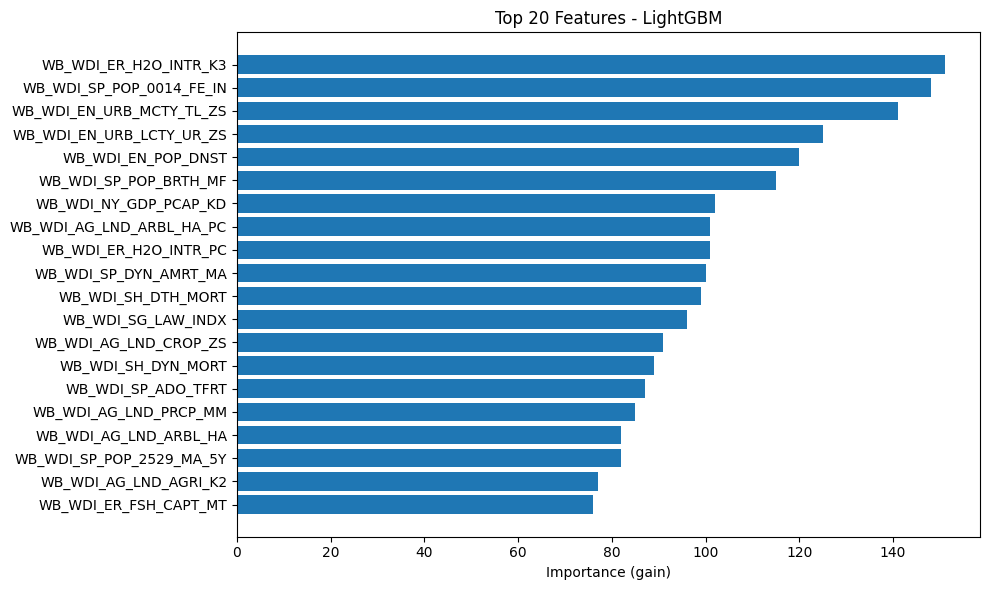

In [26]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_lgb

# Si tu as un GridSearchCV pour LightGBM :
# best_model = grid_search.best_estimator_

# Récupérer la feature importance (par gain)
feature_names = X_train_train.columns
importance = best_model.feature_importances_

# Convertir en DataFrame pour trier et afficher
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher le tableau complet ou top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (gain)')
plt.title('Top 20 Features - LightGBM')
plt.tight_layout()
plt.show()


#### Tableau récap dataset 1

In [27]:
data_dataset1 = {
        'Model': ['XGBoost', 'CatBoost', 'RandomForest', 'LightGBM'],
        'Accuracy': [f"{acc_xgb_d1:.4f}",
                        f"{acc_cat_d1:.4f}",
                        f"{acc_rf_d1:.4f}",
                        f"{acc_lgb_d1:.4f}"],
        'Precision': [f"{precision_xgb_d1:.4f}",
                        f"{precision_cat_d1:.4f}",
                        f"{precision_rf_d1:.4f}",
                        f"{precision_lgb_d1:.4f}"],
        'Recall': [f"{recall_xgb_d1:.4f}",
                        f"{recall_cat_d1:.4f}",
                        f"{recall_rf_d1:.4f}",
                        f"{recall_lgb_d1:.4f}"],
        'F1-score': [f"{f1_xgb_d1:.4f}",
                        f"{f1_cat_d1:.4f}",
                        f"{f1_rf_d1:.4f}",
                        f"{f1_lgb_d1:.4f}"],
}

df_results = pd.DataFrame(data_dataset1)
df_results

,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.9292,0.9172,0.9213,0.9193
1,CatBoost,0.8899,0.8405,0.9236,0.8801
2,RandomForest,0.9194,0.8989,0.9191,0.9089
3,LightGBM,0.9253,0.9109,0.9191,0.9150


## Dataset 2 Interpolated sans PCA

#### Récupération du dataset2

In [28]:
dataset2 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset2_lagged_final.csv")
dataset2

,REF_AREA,TIME_PERIOD,WB_WDI_ER_FSH_AQUA_MT,WB_WDI_ER_FSH_CAPT_MT,WB_WDI_ER_FSH_PROD_MT,WB_WDI_NY_ADJ_DMIN_CD,WB_WDI_SM_POP_NETM,WB_WDI_SP_ADO_TFRT,WB_WDI_SP_DYN_AMRT_FE,WB_WDI_SP_DYN_AMRT_MA,...,WB_WDI_SP_POP_TOTL_FE_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_FE_ZS_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_IN_was_interpolated_lag3,WB_WDI_SP_POP_TOTL_MA_ZS_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_was_interpolated_lag3,WB_WDI_SP_RUR_TOTL_ZS_was_interpolated_lag3,WB_WDI_SP_URB_GROW_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_was_interpolated_lag3,WB_WDI_SP_URB_TOTL_IN_ZS_was_interpolated_lag3,war_nextYear
0,AFG,1963,-0.010893,-0.159337,-0.163188,-0.018595,0.270270,0.555559,1.589105,1.597300,...,False,False,False,False,False,False,True,False,False,0
1,AFG,1964,-0.010893,-0.159337,-0.163188,-0.018595,0.280237,0.560557,1.559453,1.563872,...,False,False,False,False,False,False,False,False,False,0
2,AFG,1965,-0.010893,-0.159337,-0.163188,-0.018595,0.370794,0.572219,1.530522,1.532668,...,False,False,False,False,False,False,False,False,False,0
3,AFG,1966,-0.010893,-0.159337,-0.163188,-0.018595,0.192184,0.582076,1.500768,1.500631,...,False,False,False,False,False,False,False,False,False,0
4,AFG,1967,-0.010893,-0.158912,-0.162791,-0.018595,0.273851,0.579547,1.471805,1.468611,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6436,ZWE,2019,3.624107,0.313896,0.360988,36.741186,-2.479208,0.081857,0.484677,0.474558,...,False,False,False,False,False,False,False,False,False,0
6437,ZWE,2020,3.788446,0.277513,0.330573,31.555576,-2.136938,0.083721,0.410134,0.438263,...,False,False,False,False,False,False,False,False,False,0
6438,ZWE,2021,0.892289,0.307427,0.294076,74.489079,-1.765868,0.087286,0.598119,0.702972,...,False,False,False,False,False,False,False,False,False,0
6439,ZWE,2022,1.480716,0.274178,0.276045,74.489079,-2.472220,0.090607,0.340137,0.368417,...,False,False,False,False,False,False,False,False,False,0


In [132]:
cols_to_check = [c for c in dataset2.columns if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]]
data_numeric = dataset2[cols_to_check]
corr_matrix = data_numeric.corr().abs()
threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

print(f"Colonnes à supprimer ({len(to_drop)}):", to_drop)
dataset2 = dataset2.drop(columns=list(to_drop))
print("Shape après réduction :", dataset2.shape)

Colonnes à supprimer (295): {'WB_WDI_SP_POP_1014_MA_5Y_lag3', 'WB_WDI_SP_URB_GROW_was_interpolated_lag3', 'WB_WDI_SP_RUR_TOTL_lag1', 'WB_WDI_SP_POP_65UP_TO_ZS_lag1', 'WB_WDI_SP_POP_TOTL_MA_ZS_lag1', 'WB_WDI_SP_RUR_TOTL_lag2', 'WB_WDI_SP_POP_2529_MA_5Y_lag2', 'WB_WDI_SP_POP_4044_FE_5Y_lag2', 'WB_WDI_SP_POP_80UP_FE_5Y_lag3', 'WB_WDI_SP_POP_6569_FE_5Y_lag3', 'WB_WDI_SP_POP_7579_FE_5Y_lag2', 'WB_WDI_SP_URB_TOTL_lag3', 'WB_WDI_SP_POP_TOTL_FE_IN_lag2', 'WB_WDI_SP_POP_7074_FE_5Y_lag2', 'WB_WDI_SP_POP_DPND_lag3', 'WB_WDI_SP_POP_TOTL', 'WB_WDI_ER_FSH_AQUA_MT_lag1', 'WB_WDI_SP_POP_4044_FE_5Y_lag1', 'WB_WDI_SP_POP_7074_MA_5Y_lag2', 'WB_WDI_SP_POP_65UP_TO_lag1', 'WB_WDI_SP_POP_6569_MA_5Y_lag1', 'WB_WDI_SP_POP_0014_FE_IN_lag2', 'WB_WDI_SP_POP_TOTL_FE_IN', 'WB_WDI_SP_POP_1564_MA_ZS', 'WB_WDI_SP_POP_3034_FE_5Y_lag1', 'WB_WDI_SP_POP_65UP_TO', 'WB_WDI_SP_POP_DPND_YG', 'WB_WDI_SP_DYN_TO65_MA_ZS', 'WB_WDI_SP_POP_1564_TO_ZS_lag1', 'WB_WDI_SP_POP_3034_MA_5Y_lag2', 'WB_WDI_SP_POP_1519_MA_5Y_lag1', 'WB_WDI_S

#### Découpage train/validation/test

In [29]:
train_full = dataset2[dataset2["TIME_PERIOD"] <= 2010]
test  = dataset2[dataset2["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset2   => {dataset2.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

Dataset2   => (6441, 667)
Train_full => (5424, 667)
Test       => (1017, 667)
Train_full : X_train_full => (5424, 664) - y_train_full => (5424,)
Test       : X_test       => (1017, 664) - y_test       => (1017,)
X_train_train => (4407, 664)
y_train_train => (4407,)
X_train_val   => (1017, 664)
y_train_val   => (1017,)


#### XGBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [30]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Entraînement
model_xgb.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_train, y_train_train), (X_train_val, y_train_val)], 
    verbose=False
)

# Prédiction
y_val_pred = model_xgb.predict(X_train_val)

# Évaluation
acc_xgb_d2 = accuracy_score(y_train_val, y_val_pred)
f1_xgb_d2 = f1_score(y_train_val, y_val_pred)
precision_xgb_d2 = precision_score(y_train_val, y_val_pred)
recall_xgb_d2 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_xgb_d2)
print("F1-score :", f1_xgb_d2)
print("Precision:", precision_xgb_d2)
print("Recall   :", recall_xgb_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8544739429695182
F1-score : 0.8262910798122066
Precision: 0.8648648648648649
Recall   : 0.7910112359550562

Confusion matrix:
 [[517  55]
 [ 93 352]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       572
           1       0.86      0.79      0.83       445

    accuracy                           0.85      1017
   macro avg       0.86      0.85      0.85      1017
weighted avg       0.86      0.85      0.85      1017



##### Feature importance

Top 20 features par importance :
                                        Feature  Importance
0                    WB_WDI_SP_POP_DPND_OL_lag2    0.035451
1                       WB_WDI_SP_RUR_TOTL_lag2    0.030162
2                            WB_WDI_SP_RUR_TOTL    0.021722
3                    WB_WDI_SP_POP_DPND_OL_lag3    0.019649
4                      WB_WDI_SP_POP_0014_MA_IN    0.019560
5                    WB_WDI_SP_POP_0014_TO_lag1    0.018359
6                 WB_WDI_SP_POP_0014_FE_IN_lag3    0.015741
7                       WB_WDI_SP_RUR_TOTL_lag1    0.014481
8   WB_WDI_NY_ADJ_DMIN_CD_was_interpolated_lag1    0.013761
9                      WB_WDI_SP_POP_0004_FE_5Y    0.011596
10                WB_WDI_SP_POP_6064_FE_5Y_lag3    0.010933
11                     WB_WDI_SP_POP_0014_MA_ZS    0.010567
12                WB_WDI_SP_POP_0014_FE_ZS_lag2    0.010336
13                           WB_WDI_SP_POP_TOTL    0.009456
14                WB_WDI_SP_POP_0014_TO_ZS_lag3    0.009085
15     

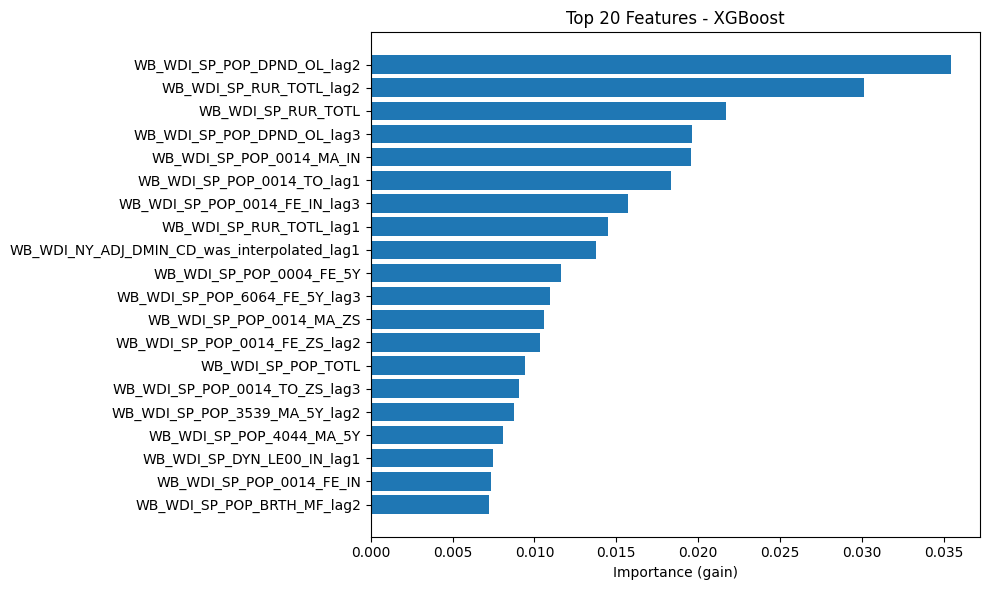

In [31]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_xgb

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

# Récupérer la feature importance par gain
importance_dict = best_model.get_booster().get_score(importance_type='gain')

# Convertir en DataFrame pour trier et afficher
importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher le tableau complet ou top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'].head(20)[::-1],
    importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (gain)')
plt.title('Top 20 Features - XGBoost')
plt.tight_layout()
plt.show()

#### CatBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [32]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],   # Classe 0 = poids 1, classe 1 = poids > 1
    random_seed=42,
    eval_metric="F1",
    loss_function="Logloss",
    verbose=0,
    early_stopping_rounds=30
)

# Entraînement
model_cat.fit(
    X_train_train, 
    y_train_train,
    eval_set=(X_train_val, y_train_val),
    verbose=0,           # affiche toutes les 50 itérations, mettre 0 pour silence total
    plot=False
)

# Prédiction
y_val_pred = model_cat.predict(X_train_val)

# Évaluation
acc_cat_d2 = accuracy_score(y_train_val, y_val_pred)
f1_cat_d2 = f1_score(y_train_val, y_val_pred)
precision_cat_d2 = precision_score(y_train_val, y_val_pred)
recall_cat_d2 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_cat_d2)
print("F1-score :", f1_cat_d2)
print("Precision:", precision_cat_d2)
print("Recall   :", recall_cat_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.7718780727630286
F1-score : 0.7578288100208769
Precision: 0.7076023391812866
Recall   : 0.8157303370786517

Confusion matrix:
 [[422 150]
 [ 82 363]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.74      0.78       572
           1       0.71      0.82      0.76       445

    accuracy                           0.77      1017
   macro avg       0.77      0.78      0.77      1017
weighted avg       0.78      0.77      0.77      1017



##### Feature importance

Top 20 features par importance :
                          Feature  Importance
0           WB_WDI_SP_POP_BRTH_MF    4.867920
1              WB_WDI_SP_RUR_TOTL    4.384326
2         WB_WDI_SP_RUR_TOTL_lag1    4.111314
3      WB_WDI_SP_POP_0014_TO_lag1    4.045254
4      WB_WDI_ER_FSH_PROD_MT_lag1    3.587270
5           WB_WDI_ER_FSH_CAPT_MT    3.568226
6      WB_WDI_SP_POP_BRTH_MF_lag2    3.278442
7      WB_WDI_SP_POP_BRTH_MF_lag3    3.180684
8   WB_WDI_SP_POP_3539_MA_5Y_lag3    2.856920
9           WB_WDI_SP_RUR_TOTL_ZS    2.422982
10     WB_WDI_ER_FSH_PROD_MT_lag3    2.043720
11     WB_WDI_SP_RUR_TOTL_ZS_lag1    2.006541
12     WB_WDI_SP_POP_65UP_TO_lag2    1.742978
13     WB_WDI_ER_FSH_CAPT_MT_lag3    1.688188
14          WB_WDI_SP_POP_0014_TO    1.586336
15        WB_WDI_SP_POP_TOTL_lag1    1.410647
16             WB_WDI_SP_POP_TOTL    1.388592
17       WB_WDI_SP_POP_0014_FE_IN    1.339984
18          WB_WDI_NY_ADJ_DMIN_CD    1.262221
19  WB_WDI_SP_POP_7579_FE_5Y_lag1    1.198736


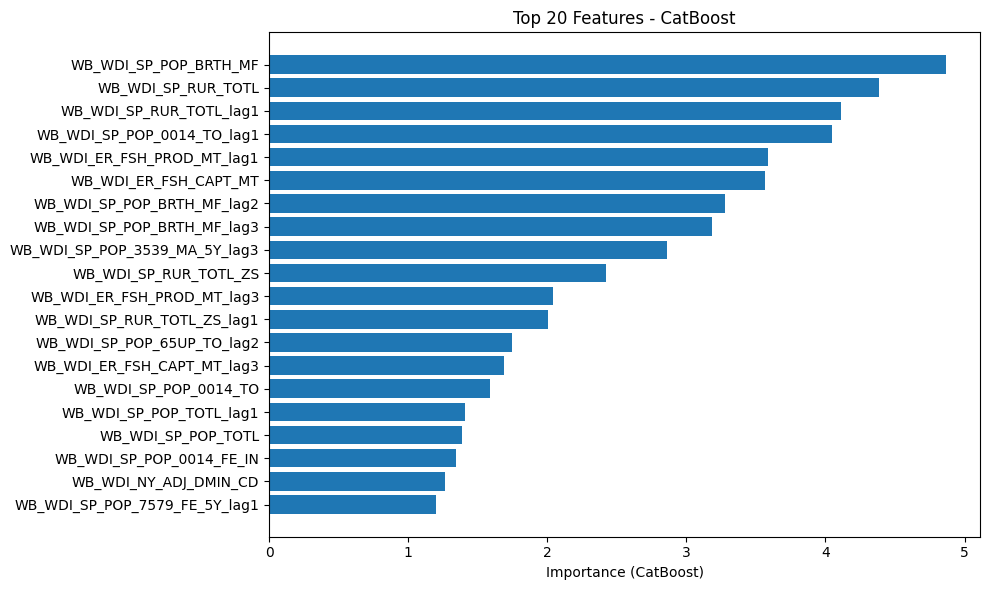

In [33]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_cat

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.get_feature_importance()

# Construire le DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Trier
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (CatBoost)')
plt.title('Top 20 Features - CatBoost')
plt.tight_layout()
plt.show()


#### RandomForest

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [34]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entraînement
model_rf.fit(
    X_train_train, 
    y_train_train
)

# Prédiction
y_val_pred = model_rf.predict(X_train_val)

# Évaluation
acc_rf_d2 = accuracy_score(y_train_val, y_val_pred)
f1_rf_d2 = f1_score(y_train_val, y_val_pred)
precision_rf_d2 = precision_score(y_train_val, y_val_pred)
recall_rf_d2 = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_rf_d2)
print("F1-score :", f1_rf_d2)
print("Precision:", precision_rf_d2)
print("Recall   :", recall_rf_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.8367748279252704
F1-score : 0.8134831460674158
Precision: 0.8134831460674158
Recall   : 0.8134831460674158

Confusion matrix:
 [[489  83]
 [ 83 362]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       572
           1       0.81      0.81      0.81       445

    accuracy                           0.84      1017
   macro avg       0.83      0.83      0.83      1017
weighted avg       0.84      0.84      0.84      1017



##### Feature importance

Top 20 features par importance :
                          Feature  Importance
0              WB_WDI_SP_RUR_TOTL    0.014244
1         WB_WDI_SP_RUR_TOTL_lag2    0.013767
2         WB_WDI_SP_RUR_TOTL_lag1    0.013475
3   WB_WDI_SP_POP_0014_FE_IN_lag3    0.011973
4         WB_WDI_SP_RUR_TOTL_lag3    0.011317
5        WB_WDI_SP_POP_0014_FE_IN    0.009262
6   WB_WDI_SP_POP_0014_MA_IN_lag1    0.009055
7      WB_WDI_SP_POP_0014_TO_lag3    0.009006
8           WB_WDI_SP_POP_0014_TO    0.008728
9        WB_WDI_SP_POP_0014_MA_IN    0.008681
10     WB_WDI_SP_POP_0014_TO_lag1    0.008531
11          WB_WDI_ER_FSH_PROD_MT    0.008021
12  WB_WDI_SP_POP_0014_FE_IN_lag1    0.007983
13     WB_WDI_SP_POP_0014_TO_lag2    0.007585
14     WB_WDI_ER_FSH_CAPT_MT_lag3    0.007148
15     WB_WDI_ER_FSH_CAPT_MT_lag1    0.006858
16       WB_WDI_SP_POP_TOTL_FE_IN    0.006730
17     WB_WDI_ER_FSH_CAPT_MT_lag2    0.006689
18          WB_WDI_ER_FSH_CAPT_MT    0.006630
19  WB_WDI_SP_POP_1564_FE_IN_lag2    0.006580


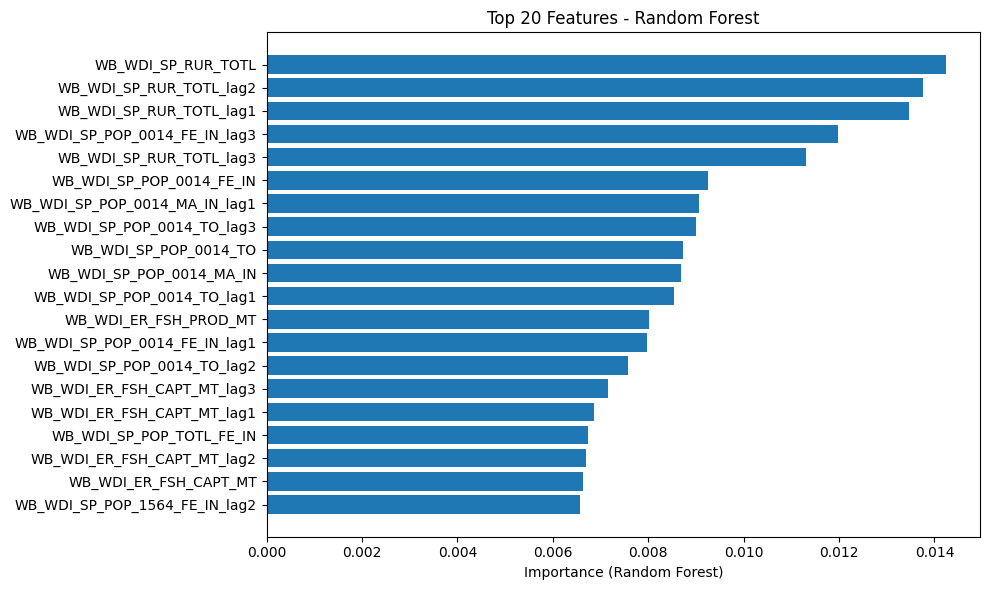

In [35]:
# Choisir le modèle à analyser
# Pour le modèle entraîné directement
best_model = model_rf

# Si tu veux analyser le meilleur modèle issu du GridSearch :
# best_model = grid_search.best_estimator_

feature_names = X_train_train.columns
importance_values = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features par importance :")
print(importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (Random Forest)')
plt.title('Top 20 Features - Random Forest')
plt.tight_layout()
plt.show()


#### MLP

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [36]:
# Normalisation indispensable
scaler = StandardScaler()
X_train_train_scaled = scaler.fit_transform(X_train_train)
X_train_val_scaled = scaler.transform(X_train_val)

model_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Entraînement
model_mlp.fit(X_train_train_scaled, y_train_train)

# Prédiction
y_pred = model_mlp.predict(X_train_val_scaled)

# Évaluation
acc_mlp_d2 = accuracy_score(y_train_val, y_pred)
f1_mlp_d2 = f1_score(y_train_val, y_pred)
precision_mlp_d2 = precision_score(y_train_val, y_pred)
recall_mlp_d2 = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_mlp_d2)
print("F1-score :", f1_mlp_d2)
print("Precision:", precision_mlp_d2)
print("Recall   :", recall_mlp_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.7826941986234022
F1-score : 0.7240948813982522
Precision: 0.8146067415730337
Recall   : 0.651685393258427

Confusion matrix:
 [[506  66]
 [155 290]]

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       572
           1       0.81      0.65      0.72       445

    accuracy                           0.78      1017
   macro avg       0.79      0.77      0.77      1017
weighted avg       0.79      0.78      0.78      1017



##### Feature importance

In [37]:
from sklearn.inspection import permutation_importance

# Attention : nécessite que le modèle soit déjà entraîné
result = permutation_importance(
    model_mlp, 
    X_train_val_scaled, 
    y_train_val, 
    scoring='f1',
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X_train_train.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features par importance (Permutation Importance) :")
print(importance_df.head(20))


Top 20 features par importance (Permutation Importance) :
                          Feature  Importance
0           WB_WDI_SP_DYN_AMRT_MA    0.022213
1        WB_WDI_SP_DYN_TO65_MA_ZS    0.021330
2        WB_WDI_SP_DYN_LE00_MA_IN    0.020624
3      WB_WDI_SP_DYN_AMRT_MA_lag3    0.018377
4   WB_WDI_SP_DYN_TO65_MA_ZS_lag1    0.015626
5   WB_WDI_SP_POP_3034_FE_5Y_lag3    0.015312
6      WB_WDI_SP_DYN_LE00_IN_lag1    0.014196
7      WB_WDI_SP_POP_BRTH_MF_lag3    0.014046
8        WB_WDI_SP_POP_7074_MA_5Y    0.014022
9      WB_WDI_NY_ADJ_DMIN_CD_lag2    0.013183
10     WB_WDI_ER_FSH_CAPT_MT_lag3    0.013077
11     WB_WDI_ER_FSH_CAPT_MT_lag2    0.012790
12     WB_WDI_NY_ADJ_DMIN_CD_lag1    0.012542
13  WB_WDI_SP_DYN_LE00_MA_IN_lag1    0.011935
14          WB_WDI_ER_FSH_CAPT_MT    0.011895
15       WB_WDI_SP_POP_6569_MA_5Y    0.011622
16     WB_WDI_SP_DYN_AMRT_MA_lag1    0.011250
17  WB_WDI_SP_POP_4044_FE_5Y_lag3    0.011212
18     WB_WDI_ER_FSH_CAPT_MT_lag1    0.011186
19       WB_WDI_SP_POP

#### GradientBoosting

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [38]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

# Créer les sample_weights : poids pour les positifs
# Ici on donne au positif un poids = scale_pos_weight, négatif = 1
sample_weight = np.where(y_train_train == 1, scale_pos_weight, 1.0)

# Définition du modèle
model_gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Entraînement avec sample_weight pour gérer le déséquilibre
model_gb.fit(X_train_train, y_train_train, sample_weight=sample_weight)

# Prédiction
y_pred = model_gb.predict(X_train_val)

# Évaluation
acc_gb_d2 = accuracy_score(y_train_val, y_pred)
f1_gb_d2 = f1_score(y_train_val, y_pred)
precision_gb_d2 = precision_score(y_train_val, y_pred)
recall_gb_d2 = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_gb_d2)
print("F1-score :", f1_gb_d2)
print("Precision:", precision_gb_d2)
print("Recall   :", recall_gb_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))

Accuracy : 0.8092428711897739
F1-score : 0.7775229357798165
Precision: 0.7939110070257611
Recall   : 0.7617977528089888

Confusion matrix:
 [[484  88]
 [106 339]]

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       572
           1       0.79      0.76      0.78       445

    accuracy                           0.81      1017
   macro avg       0.81      0.80      0.81      1017
weighted avg       0.81      0.81      0.81      1017



##### Feature importance

Top 20 features GradientBoosting:
                          Feature  Importance
0              WB_WDI_SP_RUR_TOTL    0.063294
1         WB_WDI_SP_RUR_TOTL_lag2    0.049346
2        WB_WDI_SP_POP_0014_FE_IN    0.038246
3           WB_WDI_SP_POP_BRTH_MF    0.025783
4         WB_WDI_SP_RUR_TOTL_lag3    0.023022
5           WB_WDI_ER_FSH_PROD_MT    0.018420
6           WB_WDI_ER_FSH_CAPT_MT    0.018227
7        WB_WDI_SP_POP_80UP_MA_5Y    0.017516
8   WB_WDI_SP_POP_0014_FE_IN_lag3    0.017457
9           WB_WDI_SP_DYN_AMRT_MA    0.014658
10       WB_WDI_SP_POP_0014_MA_IN    0.014625
11             WB_WDI_SP_URB_GROW    0.014501
12     WB_WDI_SP_POP_BRTH_MF_lag2    0.014009
13     WB_WDI_SP_POP_BRTH_MF_lag3    0.013995
14       WB_WDI_SP_POP_80UP_FE_5Y    0.013636
15  WB_WDI_SP_POP_5559_FE_5Y_lag3    0.012088
16  WB_WDI_SP_POP_80UP_MA_5Y_lag3    0.012064
17     WB_WDI_ER_FSH_PROD_MT_lag3    0.011904
18  WB_WDI_SP_POP_3539_MA_5Y_lag2    0.011810
19             WB_WDI_SM_POP_NETM    0.011362


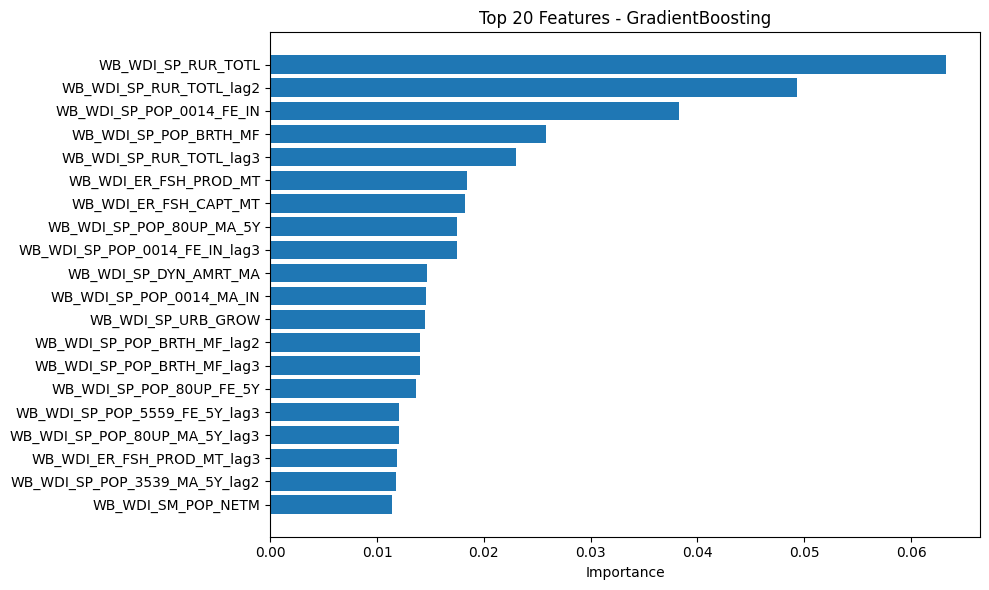

In [39]:
# Feature importance

feature_names = X_train_train.columns
importance_values = model_gb.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 20 features GradientBoosting:")
print(importance_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance')
plt.title('Top 20 Features - GradientBoosting')
plt.tight_layout()
plt.show()

#### ExtraTrees

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [40]:
# Ajustement du déséquilibre
class_weights = {0: 1, 1: scale_pos_weight}

model_et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight=class_weights,
    random_state=42
)

# Entraînement
model_et.fit(X_train_train, y_train_train)

# Prédiction
y_pred = model_et.predict(X_train_val)

# Évaluation
acc_et_d2 = accuracy_score(y_train_val, y_pred)
f1_et_d2 = f1_score(y_train_val, y_pred)
precision_et_d2 = precision_score(y_train_val, y_pred)
recall_et_d2 = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_et_d2)
print("F1-score :", f1_et_d2)
print("Precision:", precision_et_d2)
print("Recall   :", recall_et_d2)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.8475909537856441
F1-score : 0.8228571428571428
Precision: 0.8372093023255814
Recall   : 0.8089887640449438

Confusion matrix:
 [[502  70]
 [ 85 360]]

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       572
           1       0.84      0.81      0.82       445

    accuracy                           0.85      1017
   macro avg       0.85      0.84      0.84      1017
weighted avg       0.85      0.85      0.85      1017



##### Feature importance

Top 20 features par importance :
                          Feature  Importance
0   WB_WDI_SP_POP_0014_MA_IN_lag2    0.007490
1         WB_WDI_SP_RUR_TOTL_lag1    0.007000
2      WB_WDI_SP_POP_0014_TO_lag1    0.006659
3      WB_WDI_SP_POP_0014_TO_lag3    0.006559
4   WB_WDI_SP_POP_0014_FE_IN_lag3    0.006549
5        WB_WDI_SP_POP_0014_MA_IN    0.006527
6           WB_WDI_SP_POP_0014_TO    0.006477
7   WB_WDI_SP_POP_0014_MA_IN_lag1    0.006219
8      WB_WDI_SP_POP_1564_TO_lag3    0.006187
9         WB_WDI_SP_RUR_TOTL_lag3    0.006178
10  WB_WDI_SP_POP_0014_MA_IN_lag3    0.006119
11       WB_WDI_SP_POP_0014_FE_IN    0.006116
12  WB_WDI_SP_POP_0014_FE_IN_lag1    0.006089
13        WB_WDI_SP_POP_TOTL_lag3    0.006088
14     WB_WDI_SP_POP_0014_TO_lag2    0.005991
15  WB_WDI_SP_POP_0014_FE_IN_lag2    0.005990
16             WB_WDI_SP_POP_TOTL    0.005920
17             WB_WDI_SP_RUR_TOTL    0.005849
18       WB_WDI_SP_POP_TOTL_FE_IN    0.005832
19        WB_WDI_SP_RUR_TOTL_lag2    0.005770


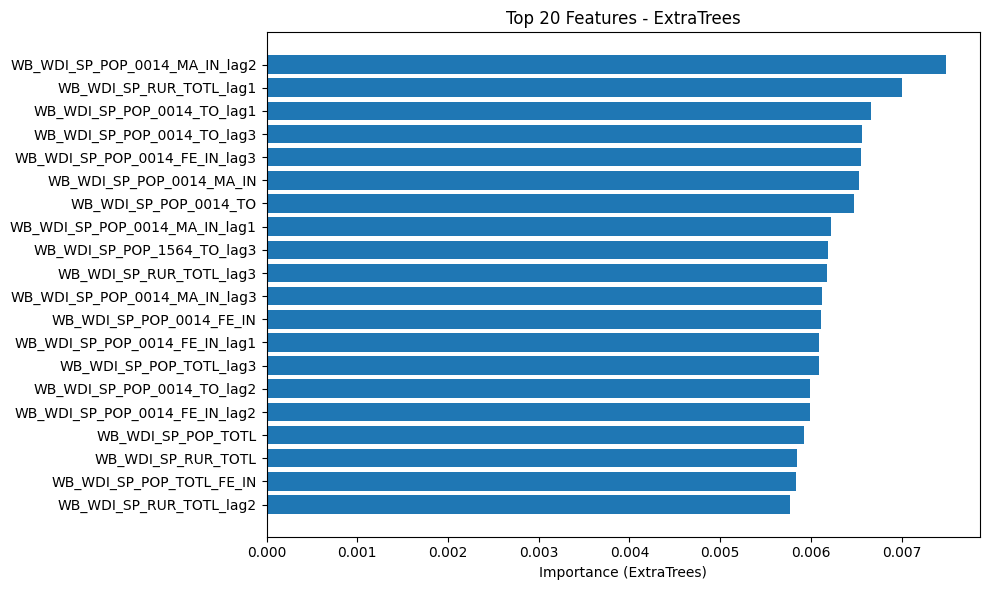

In [41]:
# Choisir le modèle à analyser
best_model = model_et

# Récupérer les importances
importance_values = best_model.feature_importances_
feature_names = X_train_train.columns

# Construire le DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Trier par importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Afficher top 20
print("Top 20 features par importance :")
print(importance_df.head(20))

# Graphique top 20
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'].head(20)[::-1], importance_df['Importance'].head(20)[::-1])
plt.xlabel('Importance (ExtraTrees)')
plt.title('Top 20 Features - ExtraTrees')
plt.tight_layout()
plt.show()


#### Tableau récap dataset 2 sans PCA

In [42]:
data_dataset2 = {
    'Model': ['XGBoost', 'CatBoost', 'RandomForest', 'MLP', 'GradientBoosting', 'ExtraTrees'],
    'Accuracy': [f"{acc_xgb_d2:.4f}",
                 f"{acc_cat_d2:.4f}",
                 f"{acc_rf_d2:.4f}",
                 f"{acc_mlp_d2:.4f}",
                 f"{acc_gb_d2:.4f}",
                 f"{acc_et_d2:.4f}"],
    'Precision': [f"{precision_xgb_d2:.4f}",
                  f"{precision_cat_d2:.4f}",
                  f"{precision_rf_d2:.4f}",
                  f"{precision_mlp_d2:.4f}",
                  f"{precision_gb_d2:.4f}",
                  f"{precision_et_d2:.4f}"],
    'Recall': [f"{recall_xgb_d2:.4f}",
               f"{recall_cat_d2:.4f}",
               f"{recall_rf_d2:.4f}",
               f"{recall_mlp_d2:.4f}",
               f"{recall_gb_d2:.4f}",
               f"{recall_et_d2:.4f}"],
    'F1-score': [f"{f1_xgb_d2:.4f}",
                 f"{f1_cat_d2:.4f}",
                 f"{f1_rf_d2:.4f}",
                 f"{f1_mlp_d2:.4f}",
                 f"{f1_gb_d2:.4f}",
                 f"{f1_et_d2:.4f}"]
}

df_results = pd.DataFrame(data_dataset2)
df_results


,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.8545,0.8649,0.7910,0.8263
1,CatBoost,0.7719,0.7076,0.8157,0.7578
2,RandomForest,0.8368,0.8135,0.8135,0.8135
3,MLP,0.7827,0.8146,0.6517,0.7241
4,GradientBoosting,0.8092,0.7939,0.7618,0.7775
5,ExtraTrees,0.8476,0.8372,0.8090,0.8229


## Dataset 2 Interpolated avec PCA

#### Récupération du dataset2 avec PCA

In [43]:
dataset2 = pd.read_csv("C:\\Users\\flori\\Documents\\Etudes\\Master\\SorbonneMIND\\M1\\Cours\\S1\\DALAS\\Projet\\ConflictPrediction/methode_lags/dataset2_lagged_pca_final.csv")
dataset2

,REF_AREA,TIME_PERIOD,PC1,PC2,war_nextYear
0,AFG,1960,-34.366684,-5.481994,0
1,AFG,1961,-34.365570,-5.482467,0
2,AFG,1962,-34.364322,-5.483265,0
3,AFG,1963,-34.362973,-5.484230,0
4,AFG,1964,-34.361601,-5.485184,0
...,...,...,...,...,...
7114,ZWE,2019,-19.194279,28.194923,0
7115,ZWE,2020,-20.681875,23.226346,0
7116,ZWE,2021,-9.811223,64.857877,0
7117,ZWE,2022,-9.251290,64.668974,0


#### Découpage train/validation/test

In [44]:
train_full = dataset2[dataset2["TIME_PERIOD"] <= 2010]
test  = dataset2[dataset2["TIME_PERIOD"] >= 2012]

# Découpage pour TimeSeriesSplit pour hyperparameter tunning
X_train_full = train_full.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_full = train_full["war_nextYear"]

# Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning
split_year = train_full["TIME_PERIOD"].quantile(0.8)
# print("Split year =", split_year) # Split year = 2001.0
X_train_train = train_full[train_full["TIME_PERIOD"] <= split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_train = train_full[train_full["TIME_PERIOD"] <= split_year]["war_nextYear"]
X_train_val = train_full[train_full["TIME_PERIOD"] > split_year].drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_train_val = train_full[train_full["TIME_PERIOD"] > split_year]["war_nextYear"]
# Fin Découpage supplémentaire à la main pour entraînement final avec hyperparameter tunning

# Test pas de découpage
X_test = test.drop(columns=["REF_AREA", "TIME_PERIOD", "war_nextYear"])
y_test = test["war_nextYear"]

print(f"Dataset2   => {dataset2.shape}")
print(f"Train_full => {train_full.shape}")
print(f"Test       => {test.shape}")
print(f"Train_full : X_train_full => {X_train_full.shape} - y_train_full => {y_train_full.shape}")
print(f"Test       : X_test       => {X_test.shape} - y_test       => {y_test.shape}")

print(f"X_train_train => {X_train_train.shape}")
print(f"y_train_train => {y_train_train.shape}")
print(f"X_train_val   => {X_train_val.shape}")
print(f"y_train_val   => {y_train_val.shape}")

Dataset2   => (7119, 5)
Train_full => (5763, 5)
Test       => (1356, 5)
Train_full : X_train_full => (5763, 2) - y_train_full => (5763,)
Test       : X_test       => (1356, 2) - y_test       => (1356,)
X_train_train => (4633, 2)
y_train_train => (4633,)
X_train_val   => (1130, 2)
y_train_val   => (1130,)


#### XGBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [45]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Entraînement
model_xgb.fit(
    X_train_train, 
    y_train_train, 
    eval_set=[(X_train_train, y_train_train), (X_train_val, y_train_val)], 
    verbose=False
)

# Prédiction
y_val_pred = model_xgb.predict(X_train_val)

# Évaluation
acc_xgb_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_xgb_d2_pca = f1_score(y_train_val, y_val_pred)
precision_xgb_d2_pca = precision_score(y_train_val, y_val_pred)
recall_xgb_d2_pca = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_xgb_d2_pca)
print("F1-score :", f1_xgb_d2_pca)
print("Precision:", precision_xgb_d2_pca)
print("Recall   :", recall_xgb_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.5637168141592921
F1-score : 0.5804255319148937
Precision: 0.5029498525073747
Recall   : 0.6861167002012073

Confusion matrix:
 [[296 337]
 [156 341]]

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.47      0.55       633
           1       0.50      0.69      0.58       497

    accuracy                           0.56      1130
   macro avg       0.58      0.58      0.56      1130
weighted avg       0.59      0.56      0.56      1130



#### CatBoost

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [46]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=[1, scale_pos_weight],   # Classe 0 = poids 1, classe 1 = poids > 1
    random_seed=42,
    eval_metric="F1",
    loss_function="Logloss",
    verbose=0,
    early_stopping_rounds=30
)

# Entraînement
model_cat.fit(
    X_train_train, 
    y_train_train,
    eval_set=(X_train_val, y_train_val),
    verbose=0,           # affiche toutes les 50 itérations, mettre 0 pour silence total
    plot=False
)

# Prédiction
y_val_pred = model_cat.predict(X_train_val)

# Évaluation
acc_cat_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_cat_d2_pca = f1_score(y_train_val, y_val_pred)
precision_cat_d2_pca = precision_score(y_train_val, y_val_pred)
recall_cat_d2_pca = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_cat_d2_pca)
print("F1-score :", f1_cat_d2_pca)
print("Precision:", precision_cat_d2_pca)
print("Recall   :", recall_cat_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.5380530973451327
F1-score : 0.5606060606060606
Precision: 0.48191027496382055
Recall   : 0.670020120724346

Confusion matrix:
 [[275 358]
 [164 333]]

Classification report:
               precision    recall  f1-score   support

           0       0.63      0.43      0.51       633
           1       0.48      0.67      0.56       497

    accuracy                           0.54      1130
   macro avg       0.55      0.55      0.54      1130
weighted avg       0.56      0.54      0.53      1130



#### RandomForest

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [47]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entraînement
model_rf.fit(
    X_train_train, 
    y_train_train
)

# Prédiction
y_val_pred = model_rf.predict(X_train_val)

# Évaluation
acc_rf_d2_pca = accuracy_score(y_train_val, y_val_pred)
f1_rf_d2_pca = f1_score(y_train_val, y_val_pred)
precision_rf_d2_pca = precision_score(y_train_val, y_val_pred)
recall_rf_d2_pca = recall_score(y_train_val, y_val_pred)
print("Accuracy :", acc_rf_d2_pca)
print("F1-score :", f1_rf_d2_pca)
print("Precision:", precision_rf_d2_pca)
print("Recall   :", recall_rf_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_val_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_val_pred))

Accuracy : 0.5769911504424778
F1-score : 0.5732142857142857
Precision: 0.5152487961476726
Recall   : 0.6458752515090543

Confusion matrix:
 [[331 302]
 [176 321]]

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.52      0.58       633
           1       0.52      0.65      0.57       497

    accuracy                           0.58      1130
   macro avg       0.58      0.58      0.58      1130
weighted avg       0.59      0.58      0.58      1130



#### MLP

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [48]:
# Normalisation indispensable
scaler = StandardScaler()
X_train_train_scaled = scaler.fit_transform(X_train_train)
X_train_val_scaled = scaler.transform(X_train_val)

model_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Entraînement
model_mlp.fit(X_train_train_scaled, y_train_train)

# Prédiction
y_pred = model_mlp.predict(X_train_val_scaled)

# Évaluation
acc_mlp_d2_pca = accuracy_score(y_train_val, y_pred)
f1_mlp_d2_pca = f1_score(y_train_val, y_pred)
precision_mlp_d2_pca = precision_score(y_train_val, y_pred)
recall_mlp_d2_pca = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_mlp_d2_pca)
print("F1-score :", f1_mlp_d2_pca)
print("Precision:", precision_mlp_d2_pca)
print("Recall   :", recall_mlp_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.5663716814159292
F1-score : 0.4110576923076923
Precision: 0.5104477611940299
Recall   : 0.3440643863179074

Confusion matrix:
 [[469 164]
 [326 171]]

Classification report:
               precision    recall  f1-score   support

           0       0.59      0.74      0.66       633
           1       0.51      0.34      0.41       497

    accuracy                           0.57      1130
   macro avg       0.55      0.54      0.53      1130
weighted avg       0.55      0.57      0.55      1130



#### GradientBoosting

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [49]:
# Ajustement du déséquilibre
scale_pos_weight = y_train_train.value_counts()[0] / y_train_train.value_counts()[1]

# Créer les sample_weights : poids pour les positifs
# Ici on donne au positif un poids = scale_pos_weight, négatif = 1
sample_weight = np.where(y_train_train == 1, scale_pos_weight, 1.0)

# Définition du modèle
model_gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Entraînement avec sample_weight pour gérer le déséquilibre
model_gb.fit(X_train_train, y_train_train, sample_weight=sample_weight)

# Prédiction
y_pred = model_gb.predict(X_train_val)

# Évaluation
acc_gb_d2_pca = accuracy_score(y_train_val, y_pred)
f1_gb_d2_pca = f1_score(y_train_val, y_pred)
precision_gb_d2_pca = precision_score(y_train_val, y_pred)
recall_gb_d2_pca = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_gb_d2_pca)
print("F1-score :", f1_gb_d2_pca)
print("Precision:", precision_gb_d2_pca)
print("Recall   :", recall_gb_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))

Accuracy : 0.5575221238938053
F1-score : 0.5791245791245792
Precision: 0.49782923299565845
Recall   : 0.6921529175050302

Confusion matrix:
 [[286 347]
 [153 344]]

Classification report:
               precision    recall  f1-score   support

           0       0.65      0.45      0.53       633
           1       0.50      0.69      0.58       497

    accuracy                           0.56      1130
   macro avg       0.57      0.57      0.56      1130
weighted avg       0.58      0.56      0.55      1130



#### ExtraTrees

##### Hyperparameter tunning

##### Entraînement avec meilleur hyperparamètre

In [50]:
# Ajustement du déséquilibre
class_weights = {0: 1, 1: scale_pos_weight}

model_et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight=class_weights,
    random_state=42
)

# Entraînement
model_et.fit(X_train_train, y_train_train)

# Prédiction
y_pred = model_et.predict(X_train_val)

# Évaluation
acc_et_d2_pca = accuracy_score(y_train_val, y_pred)
f1_et_d2_pca = f1_score(y_train_val, y_pred)
precision_et_d2_pca = precision_score(y_train_val, y_pred)
recall_et_d2_pca = recall_score(y_train_val, y_pred)
print("Accuracy :", acc_et_d2_pca)
print("F1-score :", f1_et_d2_pca)
print("Precision:", precision_et_d2_pca)
print("Recall   :", recall_et_d2_pca)
print("\nConfusion matrix:\n", confusion_matrix(y_train_val, y_pred))
print("\nClassification report:\n", classification_report(y_train_val, y_pred))


Accuracy : 0.5716814159292035
F1-score : 0.5607985480943739
Precision: 0.5107438016528926
Recall   : 0.6217303822937625

Confusion matrix:
 [[337 296]
 [188 309]]

Classification report:
               precision    recall  f1-score   support

           0       0.64      0.53      0.58       633
           1       0.51      0.62      0.56       497

    accuracy                           0.57      1130
   macro avg       0.58      0.58      0.57      1130
weighted avg       0.58      0.57      0.57      1130



#### Tableau récap dataset 2 avec PCA

In [51]:
data_dataset2_pca = {
    'Model': ['XGBoost', 'CatBoost', 'RandomForest', 'MLP', 'GradientBoosting', 'ExtraTrees'],
    'Accuracy': [f"{acc_xgb_d2_pca:.4f}",
                 f"{acc_cat_d2_pca:.4f}",
                 f"{acc_rf_d2_pca:.4f}",
                 f"{acc_mlp_d2_pca:.4f}",
                 f"{acc_gb_d2_pca:.4f}",
                 f"{acc_et_d2_pca:.4f}"],
    'Precision': [f"{precision_xgb_d2_pca:.4f}",
                  f"{precision_cat_d2_pca:.4f}",
                  f"{precision_rf_d2_pca:.4f}",
                  f"{precision_mlp_d2_pca:.4f}",
                  f"{precision_gb_d2_pca:.4f}",
                  f"{precision_et_d2_pca:.4f}"],
    'Recall': [f"{recall_xgb_d2_pca:.4f}",
               f"{recall_cat_d2_pca:.4f}",
               f"{recall_rf_d2_pca:.4f}",
               f"{recall_mlp_d2_pca:.4f}",
               f"{recall_gb_d2_pca:.4f}",
               f"{recall_et_d2_pca:.4f}"],
    'F1-score': [f"{f1_xgb_d2_pca:.4f}",
                 f"{f1_cat_d2_pca:.4f}",
                 f"{f1_rf_d2_pca:.4f}",
                 f"{f1_mlp_d2_pca:.4f}",
                 f"{f1_gb_d2_pca:.4f}",
                 f"{f1_et_d2_pca:.4f}"]
}

df_results = pd.DataFrame(data_dataset2_pca)
df_results


,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.5637,0.5029,0.6861,0.5804
1,CatBoost,0.5381,0.4819,0.6700,0.5606
2,RandomForest,0.5770,0.5152,0.6459,0.5732
3,MLP,0.5664,0.5104,0.3441,0.4111
4,GradientBoosting,0.5575,0.4978,0.6922,0.5791
5,ExtraTrees,0.5717,0.5107,0.6217,0.5608


## Tableau récapitulatif final

In [52]:
data_long = []

datasets = [('Dataset 1', data_dataset1), ('Dataset 2', data_dataset2), ('Dataset 2 PCA', data_dataset2_pca)]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
model_order = ['XGBoost', 'CatBoost', 'RandomForest', 'LightGBM', 'MLP', 'GradientBoosting', 'ExtraTrees']

for ds_name, data_dict in datasets:
    models = data_dict['Model']
    for metric in metrics:
        for model, value in zip(models, data_dict[metric]):
            data_long.append({
                'Dataset': ds_name,
                'Metric': metric,
                'Model': model,
                'Value': float(value)
            })

df_long = pd.DataFrame(data_long)

# Pivot pour avoir les modèles en colonnes, datasets en lignes, métriques en sous-index
df_pivot = df_long.pivot_table(index=['Dataset', 'Metric'], columns='Model', values='Value')
df_pivot = df_pivot.reindex(columns=model_order)

df_pivot

Model                    XGBoost  CatBoost  RandomForest  LightGBM     MLP  \
Dataset       Metric                                                         
Dataset 1     Accuracy    0.9292    0.8899        0.9194    0.9253     NaN   
              F1-score    0.9193    0.8801        0.9089    0.9150     NaN   
              Precision   0.9172    0.8405        0.8989    0.9109     NaN   
              Recall      0.9213    0.9236        0.9191    0.9191     NaN   
Dataset 2     Accuracy    0.8545    0.7719        0.8368       NaN  0.7827   
              F1-score    0.8263    0.7578        0.8135       NaN  0.7241   
              Precision   0.8649    0.7076        0.8135       NaN  0.8146   
              Recall      0.7910    0.8157        0.8135       NaN  0.6517   
Dataset 2 PCA Accuracy    0.5637    0.5381        0.5770       NaN  0.5664   
              F1-score    0.5804    0.5606        0.5732       NaN  0.4111   
              Precision   0.5029    0.4819        0.5152       NaN  0.5104   
              Recall      0.6861    0.6700        0.6459       NaN  0.3441   

Model                    GradientBoosting  ExtraTrees  
Dataset       Metric                                   
Dataset 1     Accuracy                NaN         NaN  
              F1-score                NaN         NaN  
              Precision               NaN         NaN  
              Recall                  NaN         NaN  
Dataset 2     Accuracy             0.8092      0.8476  
              F1-score             0.7775      0.8229  
              Precision            0.7939      0.8372  
              Recall               0.7618      0.8090  
Dataset 2 PCA Accuracy             0.5575      0.5717  
              F1-score             0.5791      0.5608  
              Precision            0.4978      0.5107  
              Recall               0.6922      0.6217